In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd()))

import itertools
import math
import os
import pickle
import re
import tempfile
import uuid
import warnings

import arch.unitroot as au
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rpy2.robjects as robjects
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from rpy2.robjects import globalenv, pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr, isinstalled
import rpy2.rinterface_lib.callbacks
from scipy import stats
from scipy.stats import chi2, f, friedmanchisquare, shapiro
from statsmodels.formula.api import ols
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.ardl import ARDL, ardl_select_order
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.x13 import x13_arima_analysis

os.environ['RPY2_CFFI_MODE'] = 'ABI'


In [2]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx',skiprows=1 , sheet_name = 'data')
households_structure = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=1, sheet_name = 'Фин пол ДХ')
households_loans = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', sheet_name = 'КЖН (рейтинг)')
funds_coefficient = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=2, sheet_name = 'Коэф фондов')
pickle_filename = 'region_cluster_dataset.pkl'
df_roisfix = pd.read_excel('roisfix.xlsx') # скорректированный ROISFIX из Тейлора
df_roisfix = df_roisfix.drop(columns=['Unnamed: 0'])
with open(pickle_filename, 'rb') as f:
    df_region_cluster = pickle.load(f)

In [3]:
df_region_cluster.head()

,Region,Cluster_1,Cluster_2
0,Алтайский край,1,0
1,Амурская область,0,1
2,Архангельская область,1,0
3,Астраханская область,1,0
4,Белгородская область,0,0


In [4]:
# df_roisfix.head()

In [5]:
# Преобразование даты 
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Num_reg','Date'])

In [6]:
df_reg.head()

,Num_reg,Region,Date,D_top5_rozn,Cred_nagr,Zakred,Zadolg_Fl,Zadolg_Mort,Zadolg_ConsCred,Zadolg_Fl_mom,...,New_Loans_Progr_DOMRF_mom,New_Loans_Progr_mom,Int_Rate_FL,Int_Rate_Mort,Int_Rate_ConsCred,Int_Rate_Progr_DOMRF,Int_Rate_Progr,Fin_Dostup,LTV_proksi,Credit_impulse
0,1,Белгородская область,2019-02-01,0.720458,0.327789,45.661946,1.252168e+08,43448108.04,81768732.08,1.008396,...,NaN,NaN,13.637133,9.822596,14.919927,5.714816,NaN,24.878034,0.727030,-2.177079
1,1,Белгородская область,2019-03-01,0.721863,0.332653,46.108548,1.268473e+08,44177731.36,82669591.94,1.302566,...,-50.982514,NaN,13.764491,10.119091,15.090566,5.688207,NaN,25.004848,0.674074,0.715653
2,1,Белгородская область,2019-04-01,0.724760,0.336535,46.483680,1.288264e+08,44889934.26,83936427.82,1.561441,...,-65.329715,NaN,13.988365,10.431156,15.022465,5.503984,NaN,24.937820,0.347733,1.734442
3,1,Белгородская область,2019-05-01,0.724868,0.341271,47.069180,1.315857e+08,45651657.65,85934076.07,2.141982,...,220.452622,NaN,13.975779,10.629171,14.943737,5.496568,NaN,24.870805,0.677991,2.897391
4,1,Белгородская область,2019-06-01,0.724590,0.342186,47.580388,1.339479e+08,46227839.22,87720098.33,1.794755,...,40.154704,NaN,14.197338,10.697008,15.138499,5.278560,NaN,24.803802,0.655120,2.214858


In [7]:
df_RF.head()

,Num_reg,Region,Date,CAR_Indicator,D_Progr_mort,ROISFIX,exc_rate,exc_rate_diff,Bonds_Rate_Correct_5Y,Inflation_Expectations,Nominal_Percent_Rate,Ent_conf_ind_mining,Ent_conf_ind_manufactoring,Covid_dum,Sank_dum,Key_Rate,MIACR
0,0,РОССИЯ,2019-02-01,0.146150,0.013333,7.652000,65.810525,-0.702019,0.274500,10.362319,6.5,0,-2,0,0,7.75,7.59
1,0,РОССИЯ,2019-03-01,0.146823,0.014805,7.611500,65.092257,-0.718268,0.292500,10.144295,6.5,1,-2,0,0,7.75,7.68
2,0,РОССИЯ,2019-04-01,0.146778,0.017586,7.630000,64.603105,-0.489152,0.316818,9.004132,6.5,3,-2,0,0,7.75,7.75
3,0,РОССИЯ,2019-05-01,0.145500,0.019362,7.635556,64.818706,0.215601,0.295714,9.416996,6.5,1,-1,0,0,7.75,7.72
4,0,РОССИЯ,2019-06-01,0.144882,0.027592,7.524737,64.169050,-0.649656,0.197895,9.280142,6.5,1,-1,0,0,7.50,7.58


In [8]:
###############################
# АНАЛИЗ ПАНЕЛЬНЫХ ДАННЫХ
###############################
pickle_filename = 'mon_shock_dataset.pkl'
with open(pickle_filename, 'rb') as f:
    df_shocks = pickle.load(f)
df_shocks['Date'] = pd.to_datetime(df_shocks['Date'])

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

df_reg['Date'] = pd.to_datetime(df_reg['Date'])

#  ДОБАВЛЯЕМ КЛАСТЕРЫ 
df_reg = df_reg.merge(df_region_cluster, on='Region', how='left')

# ============ ФЕДЕРАЛЬНЫЕ ПЕРЕМЕННЫЕ ============
df_reg = df_reg.merge(df_shocks[['Date', 'Mon_Shock']], on='Date', how='left')

df_rf_extra = df_RF[['Date', 'Bonds_Rate_Correct_5Y', 'Inflation_Expectations', 'exc_rate', 'MIACR', 'Covid_dum', 'Sank_dum']].copy()
df_roisf = df_roisfix[['Date', 'd_ln_ROISFIX']]
df_rf_extra = df_rf_extra.merge(df_roisf, on='Date', how='left')
df_reg = df_reg.merge(df_rf_extra, on='Date', how='left')
df_reg.rename(columns={'exc_rate': 'Exc_rate'}, inplace=True)

# Создаем лаги
df_reg['Int_Rate_FL_lag1'] = df_reg.groupby('Region')['Int_Rate_FL'].shift(1)
df_reg['Int_Rate_Mort_lag1'] = df_reg.groupby('Region')['Int_Rate_Mort'].shift(1)
df_reg['Int_Rate_ConsCred_lag1'] = df_reg.groupby('Region')['Int_Rate_ConsCred'].shift(1)

# СПИСОК ПЕРЕМЕННЫХ
initial_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y',
    'Cluster_1',
    'Cluster_2',
    'New_Loans_Progr',
    'MIACR',
    'Covid_dum',
    'Sank_dum',
    'd_ln_ROISFIX'
]

df_reg_analys = df_reg[['Region', 'Date'] + initial_vars].copy()
df_reg_analys = df_reg_analys[df_reg_analys['Region'] != 'Москва']
cols_for_drop = [c for c in df_reg_analys.columns if c not in ['New_Loans_Progr']]
df_reg_analys = df_reg_analys.dropna(subset=cols_for_drop)

In [9]:
df_reg_analys.head()

,Region,Date,Int_Rate_FL,Int_Rate_FL_lag1,Int_Rate_Mort,Credit_impulse,Int_Rate_Mort_lag1,Int_Rate_ConsCred,Int_Rate_ConsCred_lag1,Cred_nagr,...,Exc_rate,Inflation_Expectations,Bonds_Rate_Correct_5Y,Cluster_1,Cluster_2,New_Loans_Progr,MIACR,Covid_dum,Sank_dum,d_ln_ROISFIX
1,Белгородская область,2019-03-01,13.764491,13.637133,10.119091,0.715653,9.822596,15.090566,14.919927,0.332653,...,65.092257,10.144295,0.292500,0,0,NaN,7.68,0,0,-0.005307
2,Белгородская область,2019-04-01,13.988365,13.764491,10.431156,1.734442,10.119091,15.022465,15.090566,0.336535,...,64.603105,9.004132,0.316818,0,0,NaN,7.75,0,0,0.002428
3,Белгородская область,2019-05-01,13.975779,13.988365,10.629171,2.897391,10.431156,14.943737,15.022465,0.341271,...,64.818706,9.416996,0.295714,0,0,NaN,7.72,0,0,0.000728
4,Белгородская область,2019-06-01,14.197338,13.975779,10.697008,2.214858,10.629171,15.138499,14.943737,0.342186,...,64.169050,9.280142,0.197895,0,0,NaN,7.58,0,0,-0.014620
5,Белгородская область,2019-07-01,13.855339,14.197338,10.354990,0.904920,10.697008,14.936965,15.138499,0.343333,...,63.222682,9.344961,0.210870,0,0,NaN,7.32,0,0,-0.024679


In [10]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6630 entries, 1 to 6882
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Region                  6630 non-null   object        
 1   Date                    6630 non-null   datetime64[ns]
 2   Int_Rate_FL             6630 non-null   float64       
 3   Int_Rate_FL_lag1        6630 non-null   float64       
 4   Int_Rate_Mort           6630 non-null   float64       
 5   Credit_impulse          6630 non-null   float64       
 6   Int_Rate_Mort_lag1      6630 non-null   float64       
 7   Int_Rate_ConsCred       6630 non-null   float64       
 8   Int_Rate_ConsCred_lag1  6630 non-null   float64       
 9   Cred_nagr               6630 non-null   float64       
 10  D_top5_rozn             6630 non-null   float64       
 11  Fin_Dostup              6630 non-null   float64       
 12  Cred_structure          6630 non-null   float64      

In [11]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y'
]


def detect_outlier_regions_iqr(df, key_vars, min_obs=60, max_na_pct=0.3):
    """
    Определение выбросов по IQR (межквартильный размах)
    """
    region_stats = []
    
    for region in df['Region'].unique():
        reg_data = df[df['Region'] == region][key_vars].dropna()
        
        # 1. Минимум наблюдений
        n_obs = len(reg_data)
        if n_obs < min_obs:
            region_stats.append({
                'Region': region,
                'N_obs': n_obs,
                'Reason': f'Мало данных (<{min_obs})',
                'Status': 'EXCLUDE'
            })
            continue
        
        # 2. % пропусков
        total_rows = len(df[df['Region'] == region])
        na_pct = 1 - (n_obs / total_rows)
        if na_pct > max_na_pct:
            region_stats.append({
                'Region': region,
                'N_obs': n_obs,
                'NA_pct': f'{na_pct:.1%}',
                'Reason': f'Много пропусков (>{max_na_pct*100}%)',
                'Status': 'EXCLUDE'
            })
            continue
        
        # 3. IQR по переменным
        iqr_outliers = []
        for col in key_vars:
            if col in reg_data.columns:
                data = reg_data[col].dropna()
                if len(data) > 0:
                    Q1 = data.quantile(0.15)
                    Q3 = data.quantile(0.85)
                    IQR = Q3 - Q1
                    lower_bound = Q1 - 1.5 * IQR
                    upper_bound = Q3 + 1.5 * IQR
                    outliers = ((data < lower_bound) | (data > upper_bound)).sum()
                    iqr_outliers.append(outliers)
        
        iqr_total = sum(iqr_outliers)
        iqr_pct = iqr_total / n_obs if n_obs > 0 else 0

        
        # РЕШЕНИЕ
        status = 'KEEP'
        reasons = []
        
        if iqr_pct > 0.2:  # >20% выбросов по IQR
            reasons.append(f'Много выбросов по IQR ({iqr_pct:.1%})')
            status = 'EXCLUDE'
        
        region_stats.append({
            'Region': region,
            'N_obs': n_obs,
            'NA_pct': f'{na_pct:.1%}',
            'IQR_outliers': iqr_total,
            'IQR_pct': f'{iqr_pct:.1%}',
            'Reasons': '; '.join(reasons),
            'Status': status
        })
    
    return pd.DataFrame(region_stats)

# АНАЛИЗ РЕГИОНОВ ПО IQR
region_quality_iqr = detect_outlier_regions_iqr(df_reg_analys, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# ФИЛЬТРАЦИЯ ДАННЫХ
df_reg_analys= df_reg_analys[df_reg_analys['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_reg_analys.shape}")





ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 85 РЕГИОНОВ (IQR)
                                              Region  N_obs NA_pct  IQR_outliers IQR_pct                       Reasons  Status
                                Белгородская область     78   0.0%             4    5.1%                                  KEEP
                                    Брянская область     78   0.0%             4    5.1%                                  KEEP
                                Владимирская область     78   0.0%             4    5.1%                                  KEEP
                                 Воронежская область     78   0.0%             4    5.1%                                  KEEP
                                  Ивановская область     78   0.0%             3    3.8%                                  KEEP
                                    Тверская область     78   0.0%             3    3.8%                                  KEEP
                                   Калужская область

In [12]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
descriptive_df = df_reg_analys[[
    'Int_Rate_FL',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_ConsCred',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y',
    'Cluster_1',
    'Cluster_2',
    'New_Loans_Progr',
    'Covid_dum',
    'Sank_dum'
]]
desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
                            Среднее     Медиана    ст. откл.     Мин.  \
Int_Rate_FL                  14.231      13.163        3.448    9.100   
Int_Rate_Mort                 8.245       8.061        1.334    3.327   
Credit_impulse               -0.646      -0.171        6.504  -59.204   
Int_Rate_ConsCred            18.036      15.876        5.667   -8.170   
Cred_nagr                     0.352       0.356        0.084    0.072   
D_top5_rozn                   0.784       0.781        0.063    0.614   
Fin_Dostup                   19.221      18.651        6.003    2.972   
Cred_structure                0.467       0.470        0.065    0.147   
Def_Zadolg_Fl                 4.247       4.189        1.123    1.407   
Def_Zadolg_Mort               0.618       0.474        0.514    0.043   
Def_Zadolg_ConsCred           7.445       7.444        1.556    2.154   
Mon_Shock                    -0.005      -0.136        1.477   -4.416  

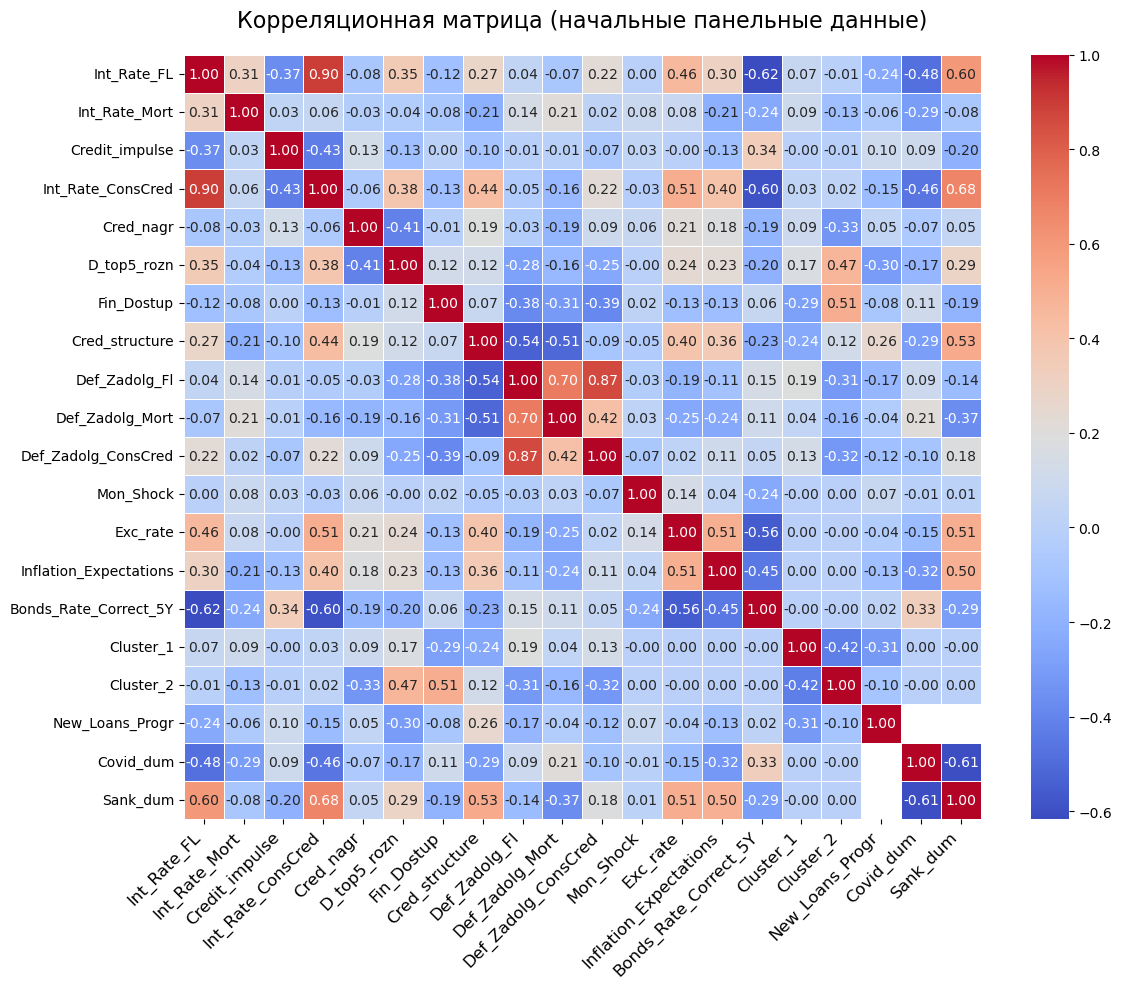

In [13]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные панельные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [14]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 1
###############################

vif_variables = [
    'Int_Rate_FL_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1
              Variable      VIF
              Sank_dum 3.770883
 Bonds_Rate_Correct_5Y 3.307266
      Int_Rate_FL_lag1 3.077582
           D_top5_rozn 2.723955
              Exc_rate 2.675226
             Cluster_2 2.570506
        Cred_structure 2.374616
         Def_Zadolg_Fl 2.179367
             Covid_dum 2.148277
Inflation_Expectations 1.846656
             Cluster_1 1.788234
             Cred_nagr 1.782442
            Fin_Dostup 1.753097
        Credit_impulse 1.484894
             Mon_Shock 1.120207


In [15]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 2
###############################

vif_variables = [
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 2")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 2
              Variable      VIF
              Sank_dum 3.929633
Int_Rate_ConsCred_lag1 3.630197
 Bonds_Rate_Correct_5Y 3.207145
           D_top5_rozn 2.789691
              Exc_rate 2.659576
             Cluster_2 2.554253
             Covid_dum 2.111859
        Cred_structure 1.858687
             Cluster_1 1.793780
             Cred_nagr 1.772630
Inflation_Expectations 1.751711
            Fin_Dostup 1.675020
   Def_Zadolg_ConsCred 1.658112
        Credit_impulse 1.517347
             Mon_Shock 1.142269


In [16]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 3
###############################

vif_variables = [
    'Int_Rate_Mort_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Mort',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]
 
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 3")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 3
              Variable      VIF
              Sank_dum 3.637825
              Exc_rate 2.895542
             Covid_dum 2.719557
 Bonds_Rate_Correct_5Y 2.597287
             Cluster_2 2.530489
           D_top5_rozn 2.467424
Inflation_Expectations 1.975593
        Cred_structure 1.963065
             Cluster_1 1.829058
    Int_Rate_Mort_lag1 1.819949
            Fin_Dostup 1.788989
       Def_Zadolg_Mort 1.737599
             Cred_nagr 1.732449
        Credit_impulse 1.469290
             Mon_Shock 1.108694


In [17]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 4
###############################

vif_variables = [
    'Int_Rate_Mort_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Mort',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'New_Loans_Progr',
    'Cluster_1',
    'Cluster_2',
]
 
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 4")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 4
              Variable      VIF
 Bonds_Rate_Correct_5Y 3.389993
              Exc_rate 3.129117
             Cluster_2 2.723775
           D_top5_rozn 2.501686
             Cluster_1 2.078529
            Fin_Dostup 1.912779
       Def_Zadolg_Mort 1.890889
    Int_Rate_Mort_lag1 1.784732
             Cred_nagr 1.766992
Inflation_Expectations 1.701798
        Credit_impulse 1.679744
        Cred_structure 1.492804
             Mon_Shock 1.397599
       New_Loans_Progr 1.301347


In [18]:
##############################
# Тест Фридмана на сезонность
##############################

variables_for_analysis = [
    ('MIACR', 'Cтавка по межбанковским кредитам (MIACR)')    
]

def friedman_seasonality_test(df, date_col='Date', value_col='Variable', 
                              test_name=None):

    df_test = df.copy()
    df_test['Month'] = df_test[date_col].dt.month
    df_test['Year'] = df_test[date_col].dt.year
    
    # Перевод в таблицу: года × месяцы
    pivot_data = df_test.pivot(index='Year', columns='Month', values=value_col)
    
    # Удаляем строки с NaN (неполные годы)
    pivot_data = pivot_data.dropna()
    
    # Проверяем достаточность данных
    if len(pivot_data) < 3:
        print(f"{test_name}: Недостаточно лет ({len(pivot_data)}), минимум 3")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': 'Недостаточно данных'
        }
    
    try:
        # Тест Фридмана
        stat, p_value = friedmanchisquare(*[pivot_data[m].values for m in pivot_data.columns])
        
        # Определяем наличие сезонности
        has_seasonality = p_value < 0.05
        
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': stat,
            'p_value': p_value,
            'has_seasonality': has_seasonality,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': None
        }
    
    except Exception as e:
        print(f"Ошибка для {test_name}: {str(e)}")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': str(e)
        }



In [19]:
# Применяем тест

friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_RF.columns:
        result = friedman_seasonality_test(df_RF, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*80)
print(friedman_summary.to_string(index=False))

    



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                                Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
Cтавка по межбанковским кредитам (MIACR)     3.774737 0.976049            False        5        12


In [20]:
#New_Loans_Progr
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6318 entries, 1 to 6882
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Region                  6318 non-null   object        
 1   Date                    6318 non-null   datetime64[ns]
 2   Int_Rate_FL             6318 non-null   float64       
 3   Int_Rate_FL_lag1        6318 non-null   float64       
 4   Int_Rate_Mort           6318 non-null   float64       
 5   Credit_impulse          6318 non-null   float64       
 6   Int_Rate_Mort_lag1      6318 non-null   float64       
 7   Int_Rate_ConsCred       6318 non-null   float64       
 8   Int_Rate_ConsCred_lag1  6318 non-null   float64       
 9   Cred_nagr               6318 non-null   float64       
 10  D_top5_rozn             6318 non-null   float64       
 11  Fin_Dostup              6318 non-null   float64       
 12  Cred_structure          6318 non-null   float64      


СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ

Курс рубля (Exc_rate):


  ✓ Успешно скорректировано, снижение волатильности: 1.6%

Инфляционные ожидания (Inflation_Expectations):
  ✓ Успешно скорректировано, снижение волатильности: 2.5%

Ставки на облигации скорректированные 5Y (Bonds_Rate_Correct_5Y):
  ✓ Успешно скорректировано, снижение волатильности: 2.4%

СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ

Ставка на кредиты ФЛ (Int_Rate_FL):
  Обрабатываю 81 регионов...
  ✓ Успешно скорректировано 81/81 регионов

Ставка на кредиты ФЛ лаг (Int_Rate_FL_lag1):
  Обрабатываю 81 регионов...
  ✓ Успешно скорректировано 81/81 регионов

Ставка на ипотеку (Int_Rate_Mort):
  Обрабатываю 81 регионов...
  ✓ Успешно скорректировано 81/81 регионов

Ставка на ипотеку лаг (Int_Rate_Mort_lag1):
  Обрабатываю 81 регионов...
  ✓ Успешно скорректировано 81/81 регионов

Кредитный импульс (Credit_impulse):
  Обрабатываю 81 регионов...
  ✓ Успешно скорректировано 81/81 регионов

Ставка на потребительский кредит (Int_Rate_ConsCred):
  Обрабатываю 81 регионов...
  ✓ Успешно скорр

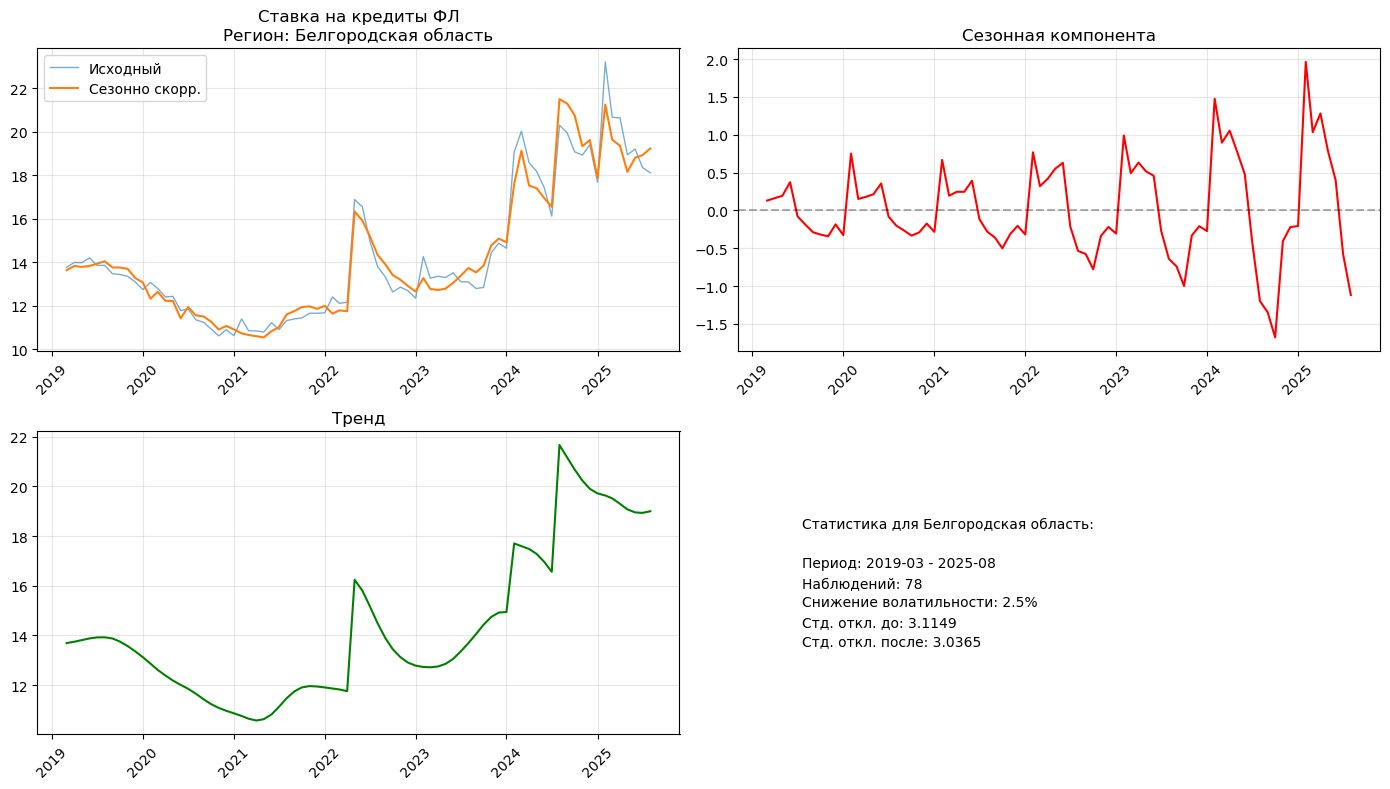

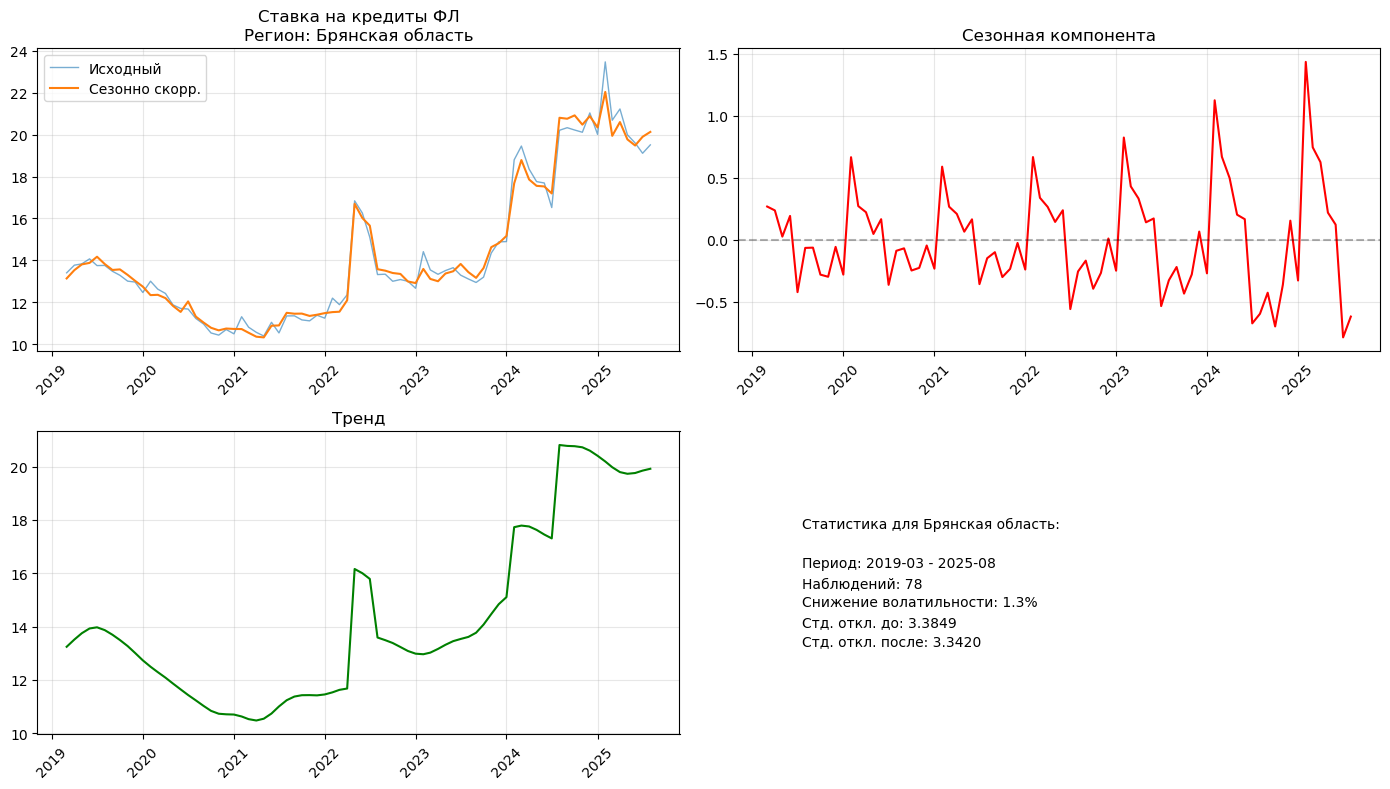

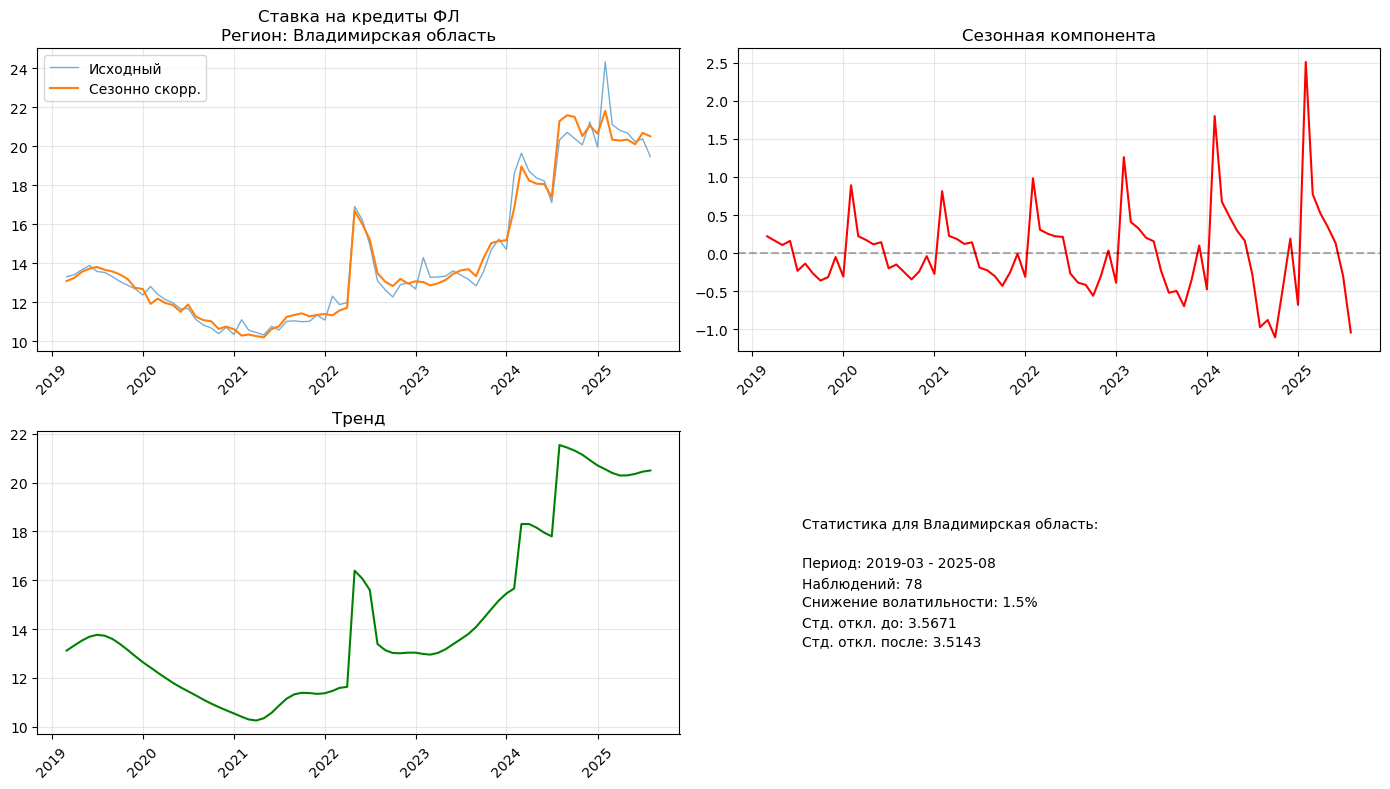

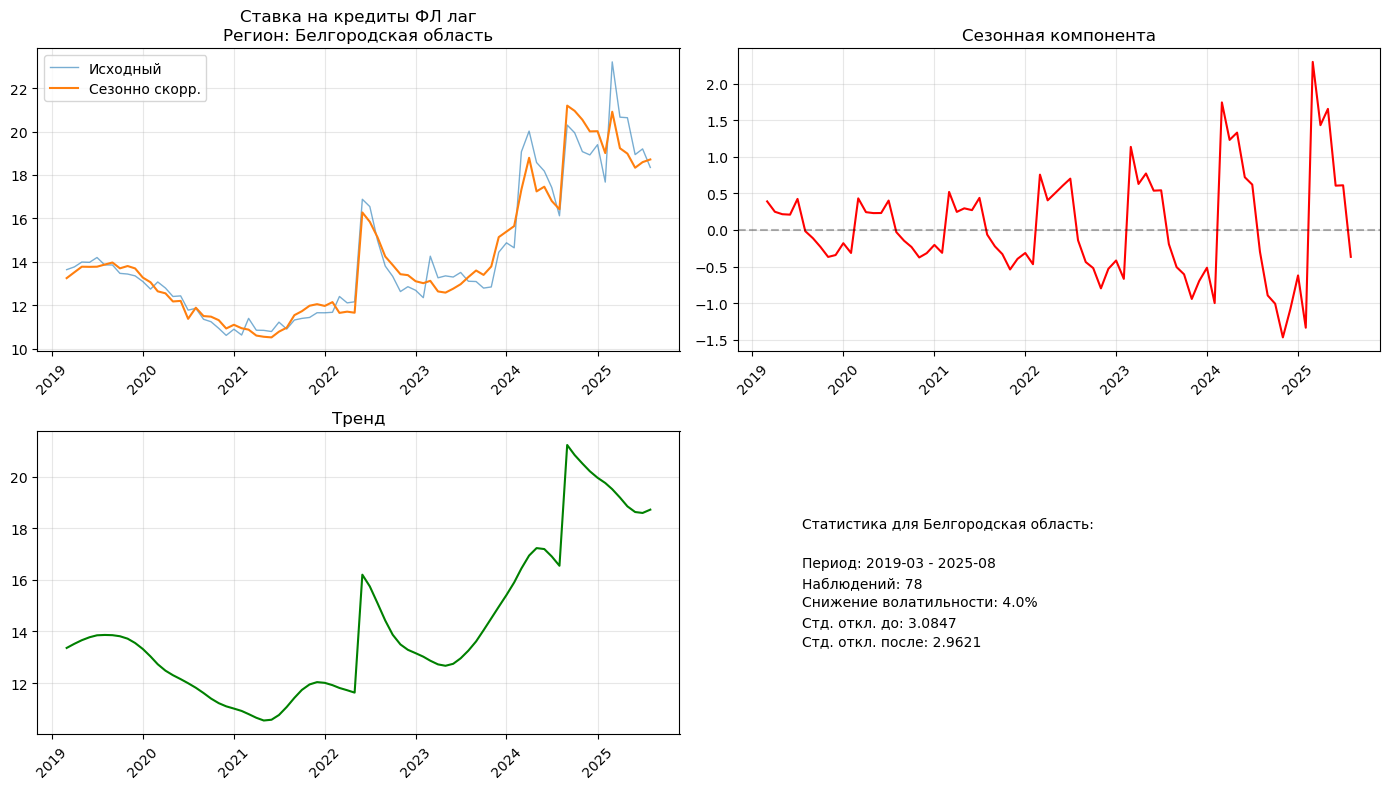

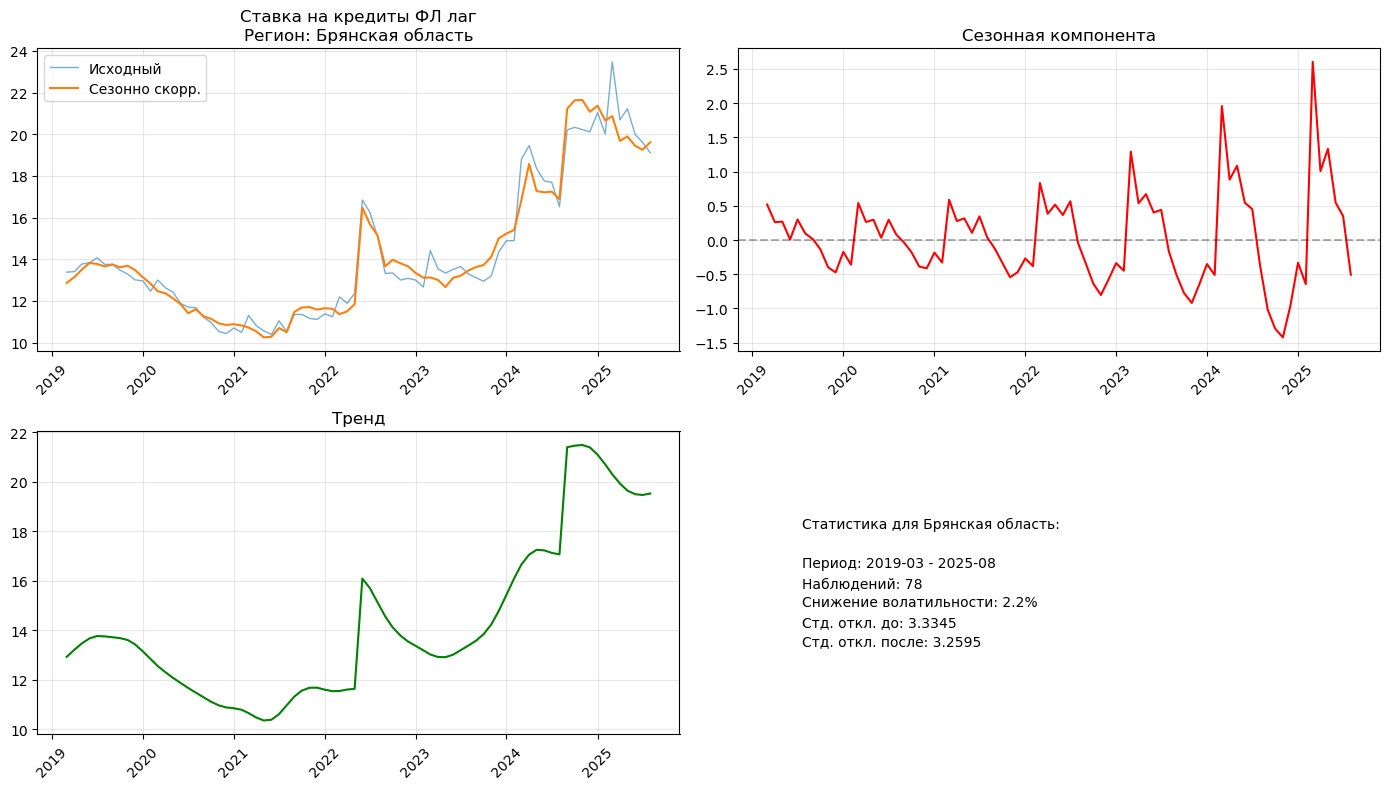

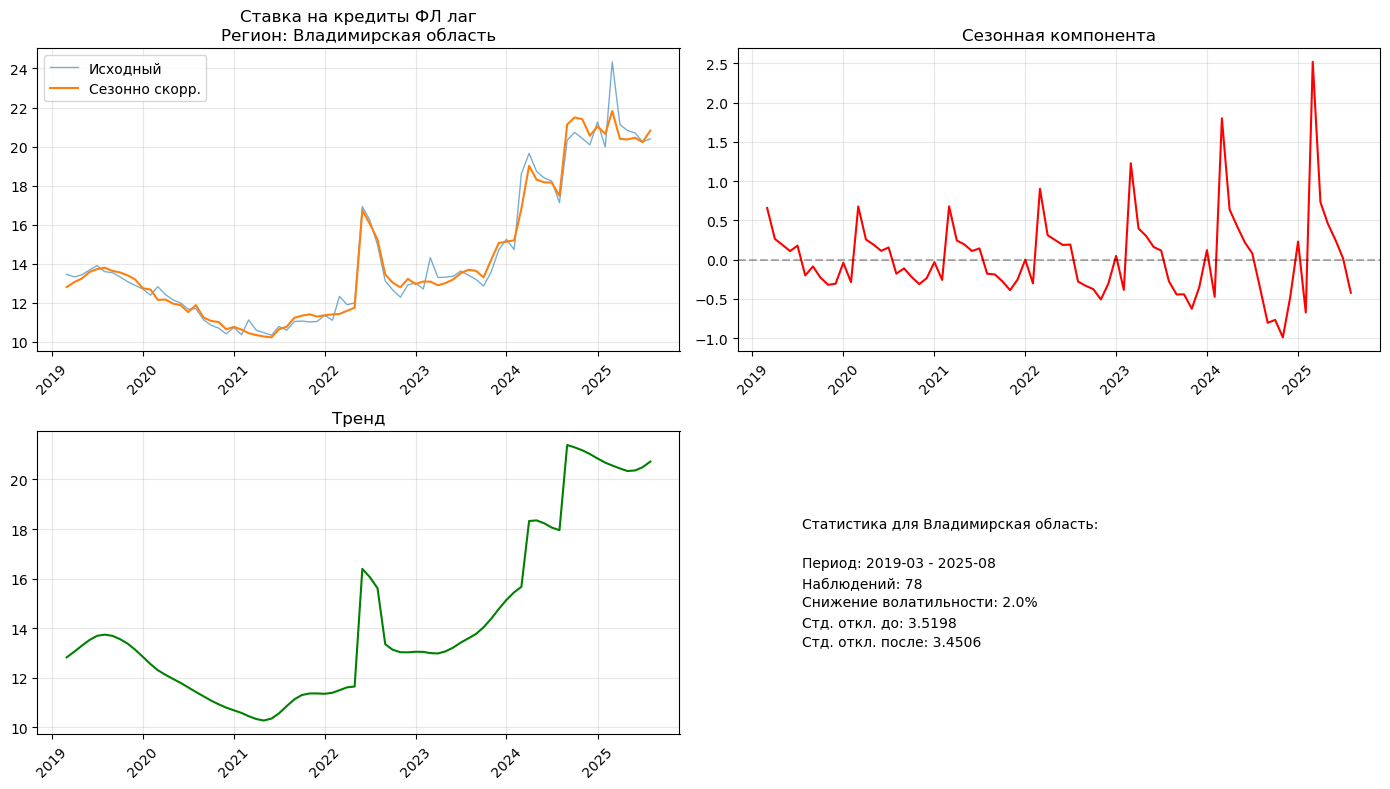


Графики федеральных переменных...


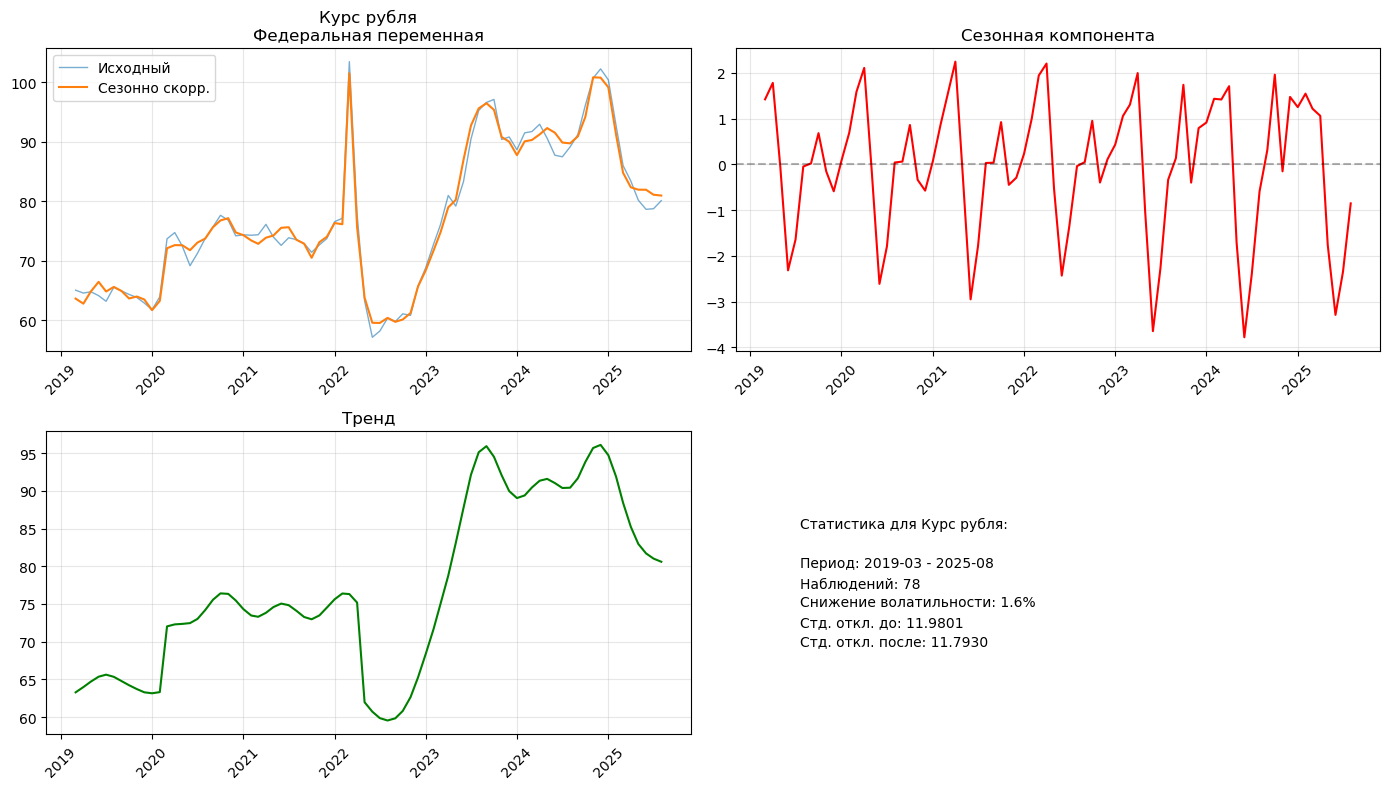

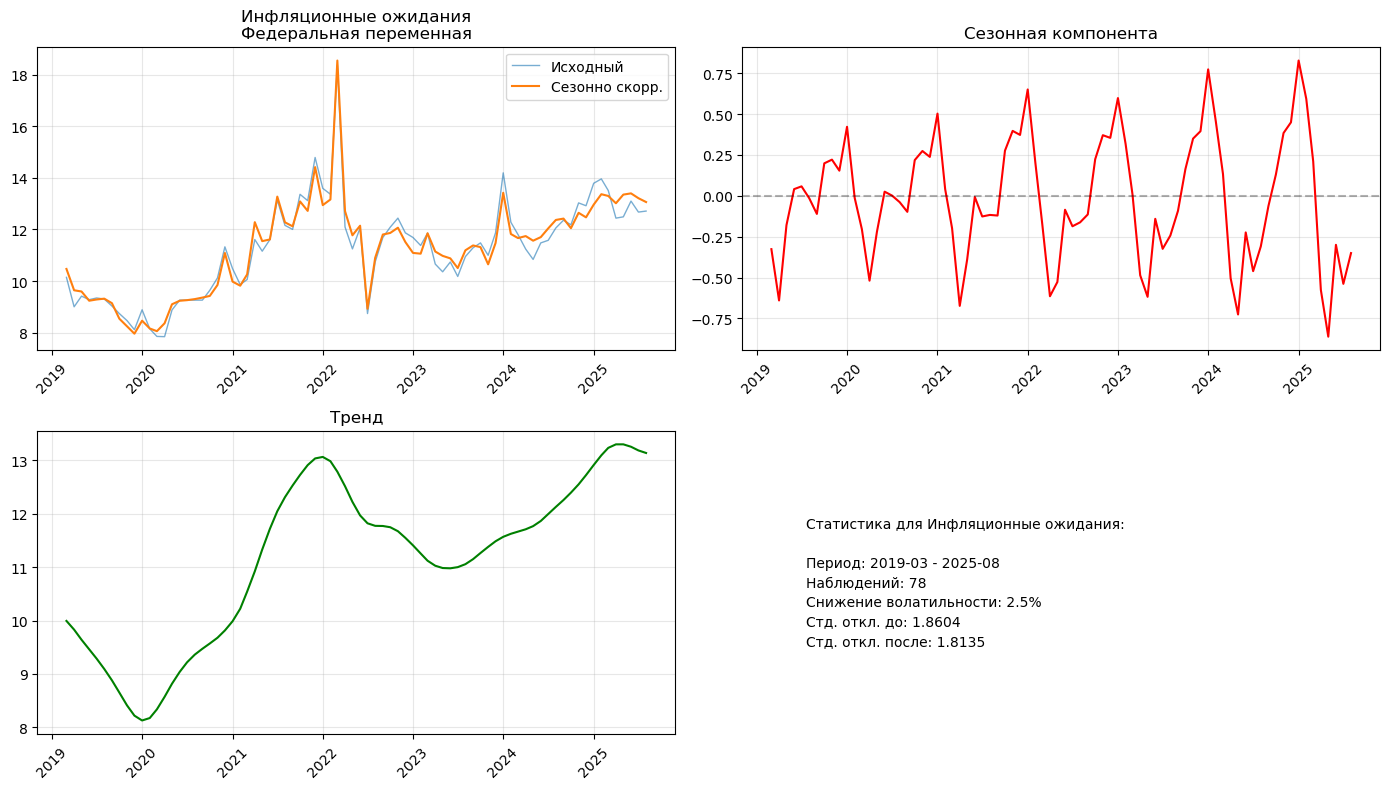

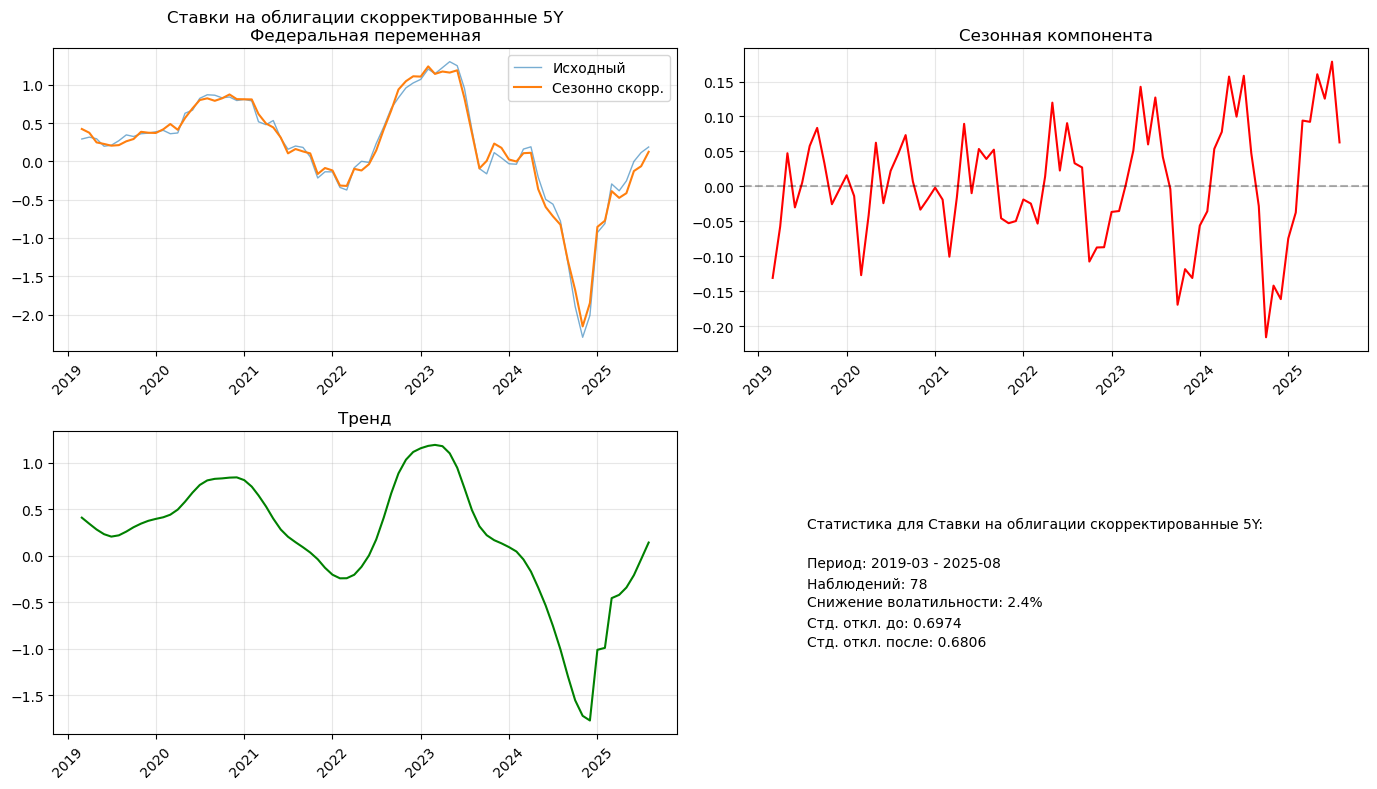


ФИНАЛЬНАЯ СТАТИСТИКА

Обработано федеральных переменных: 3/3
Обработано региональных переменных: 14/14
Общее количество добавленных столбцов: 51
Форма df_reg_analys: (6318, 78)

Столбцов _adj: 17
Столбцов _trend: 17
Столбцов _seasonal: 17

✓ Скорректированные ряды добавлены в df_reg_analys
✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)


In [21]:
# ===== СЕЗОННАЯ КОРРЕКТИРОВКА ДЛЯ ПАНЕЛЬНЫХ ДАННЫХ =====

# Заглушаем предупреждения
warnings.filterwarnings('ignore')

# Путь к бинарнику X-13
X13_PATH = "C:\\PyProjects\\CreditResearch\\x13as"

# Проверка, что бинарник доступен
if not os.path.exists(X13_PATH):
    raise FileNotFoundError(f"X-13 binary not found at {X13_PATH}")

# Если X13_PATH — полный путь к бинарнику, берем его директорию для x12path
x13_dir = X13_PATH if os.path.isdir(X13_PATH) else os.path.dirname(X13_PATH)

# Создаем папку для логов
os.makedirs("x13_logs", exist_ok=True)

# ============ ОПРЕДЕЛЕНИЕ ПЕРЕМЕННЫХ ДЛЯ КОРРЕКТИРОВКИ ============

# ФЕДЕРАЛЬНЫЕ переменные (одна серия для всех регионов)
federal_variables = {
    'Exc_rate': 'Курс рубля', 
    'Inflation_Expectations': 'Инфляционные ожидания',
    'Bonds_Rate_Correct_5Y': 'Ставки на облигации скорректированные 5Y'
}

# РЕГИОНАЛЬНЫЕ переменные (серии по каждому региону)
regional_variables = {
    'Int_Rate_FL': 'Ставка на кредиты ФЛ',
    'Int_Rate_FL_lag1' : 'Ставка на кредиты ФЛ лаг',
    'Int_Rate_Mort': 'Ставка на ипотеку',
    'Int_Rate_Mort_lag1': 'Ставка на ипотеку лаг',
    'Credit_impulse': 'Кредитный импульс',
    'Int_Rate_ConsCred': 'Ставка на потребительский кредит',
    'Int_Rate_ConsCred_lag1': 'Ставка на потребительский кредит лаг',
    'Cred_nagr': 'Кредитная нагрузка',
    'D_top5_rozn': 'Доля топ-5 банков в розничном портфеле региона',
    'Fin_Dostup':'Кол-во пунктов банковского обслуживания на 100к чел.',
    'Cred_structure':'Доля ипотечных жилищных кредитов в розничном портфеле',
    'Def_Zadolg_Fl':'Доля просроченной задолженности по кредитам физических лиц',
    'Def_Zadolg_Mort':'Доля просроченной задолженности по ипотечным жилищным кредитам',
    'Def_Zadolg_ConsCred':'Доля просроченной задолженности по потребительским кредитам'
    
}
# ============ ФУНКЦИЯ ДЛЯ СЕЗОННОЙ КОРРЕКТИРОВКИ ОДНОЙ СЕРИИ ============

def seasonal_adjust_panel_series(series_data, variable_name, region_name=None, min_obs=24):
    """
    Выполнить X-13 сезонную корректировку для одной серии (панельные данные)
    
    Parameters:
    -----------
    series_data : pd.Series
        Временной ряд с DatetimeIndex
    variable_name : str
        Название переменной
    region_name : str, optional
        Название региона (для региональных переменных)
    min_obs : int
        Minimum number of observations
    
    Returns:
    --------
    dict с результатами или None при ошибке
    """
    try:
        # Проверка данных
        if len(series_data) < min_obs:
            return None
        
        # Убедиться, что индекс - DatetimeIndex
        if not isinstance(series_data.index, pd.DatetimeIndex):
            series_data.index = pd.to_datetime(series_data.index)
        
        # Установить частоту на месячную
        ts_regular = series_data.asfreq('MS').dropna()
        
        if len(ts_regular) < min_obs:
            return None
        
        # Информация о данных
        start_date = ts_regular.index[0]
        end_date = ts_regular.index[-1]
        
        # Создаем уникальную временную папку для каждого вызова X-13
        # чтобы избежать конфликтов файлов
        temp_dir = tempfile.mkdtemp(prefix=f"x13_{uuid.uuid4().hex[:8]}_")
        
        # Запуск X-13 с указанием уникальной временной директории
        try:
            res = x13_arima_analysis(
                endog=ts_regular,
                x12path=x13_dir,
                prefer_x13=True,
                outlier=True,
                trading=False,
                print_stdout=False
            )
            
            # Извлечение компонент
            adj = res.seasadj
            trend = res.trend
            seas = ts_regular - adj
            
        except Exception as e:
            # Если X-13 не сработал, попробуем без outlier
            try:
                res = x13_arima_analysis(
                    endog=ts_regular,
                    x12path=x13_dir,
                    prefer_x13=True,
                    outlier=False,  # Без определения выбросов
                    trading=False,
                    print_stdout=False
                )
                
                adj = res.seasadj
                trend = res.trend
                seas = ts_regular - adj
                
            except Exception as e2:
                # Если все еще не работает, пропускаем
                return None
        
        # Расчёт эффективности
        original_std = ts_regular.std()
        adj_std = adj.std()
        reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0
        
        # Удаляем временную директорию
        try:
            import shutil
            shutil.rmtree(temp_dir, ignore_errors=True)
        except:
            pass
        
        return {
            'dates': ts_regular.index,
            'adj': adj.values,
            'trend': trend.values,
            'seasonal': seas.values,
            'reduction': reduction
        }
        
    except Exception as e:
        # Подавляем вывод ошибок
        return None

# ============ ОБРАБОТКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ ============

print("\n" + "="*70)
print("СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ")
print("="*70)

federal_adjusted = {}

for col, name in federal_variables.items():
    if col not in df_reg_analys.columns:
        print(f"\n  {name} ({col}): столбец не найден. Пропуск.")
        continue
    
    print(f"\n{name} ({col}):")
    
    # Для федеральных переменных берем уникальные значения по датам
    fed_data = df_reg_analys[['Date', col]].copy().dropna()
    
    if len(fed_data) == 0:
        print(f"  ✗ Нет данных. Пропуск.")
        continue
    
    # Убедиться, что одно значение на дату
    fed_data = fed_data.drop_duplicates('Date')
    fed_data = fed_data.set_index('Date')[col].sort_index()
    
    # Сезонная корректировка
    result = seasonal_adjust_panel_series(fed_data, col, region_name=None)
    
    if result is not None:
        federal_adjusted[col] = result
        print(f"  ✓ Успешно скорректировано, снижение волатильности: {result['reduction']:.1f}%")
        
        # Добавляем результаты обратно в df_reg_analys
        for date, adj_val, trend_val, seas_val in zip(
            result['dates'], result['adj'], result['trend'], result['seasonal']
        ):
            mask = df_reg_analys['Date'] == date
            df_reg_analys.loc[mask, f'{col}_adj'] = adj_val
            df_reg_analys.loc[mask, f'{col}_trend'] = trend_val
            df_reg_analys.loc[mask, f'{col}_seasonal'] = seas_val
    else:
        print(f"  ✗ Не удалось скорректировать")

# ============ ОБРАБОТКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ ============

print("\n" + "="*70)
print("СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ")
print("="*70)

regional_adjusted = {}

for col, name in regional_variables.items():
    if col not in df_reg_analys.columns:
        print(f"\n  {name} ({col}): столбец не найден. Пропуск.")
        continue
    
    print(f"\n{name} ({col}):")
    
    # Получаем список регионов
    regions = df_reg_analys['Region'].unique()
    print(f"  Обрабатываю {len(regions)} регионов...")
    
    regional_adjusted[col] = {}
    successful_regions = 0
    
    for region in regions:
        # Фильтруем данные по региону
        region_data = df_reg_analys[df_reg_analys['Region'] == region][['Date', col]].copy().dropna()
        
        if len(region_data) < 24:
            continue  # Пропускаем регионы с недостаточным количеством данных
        
        # Подготавливаем временной ряд
        region_series = region_data.set_index('Date')[col].sort_index()
        
        # Сезонная корректировка
        result = seasonal_adjust_panel_series(region_series, col, region_name=region, min_obs=24)
        
        if result is not None:
            regional_adjusted[col][region] = result
            successful_regions += 1
            
            # Добавляем результаты в df_reg_analys
            for date, adj_val, trend_val, seas_val in zip(
                result['dates'], result['adj'], result['trend'], result['seasonal']
            ):
                mask = (df_reg_analys['Region'] == region) & (df_reg_analys['Date'] == date)
                if mask.any():
                    df_reg_analys.loc[mask, f'{col}_adj'] = adj_val
                    df_reg_analys.loc[mask, f'{col}_trend'] = trend_val
                    df_reg_analys.loc[mask, f'{col}_seasonal'] = seas_val
    
    print(f"  ✓ Успешно скорректировано {successful_regions}/{len(regions)} регионов")

# ============ ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ ============

print("\n" + "="*70)
print("ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ")
print("="*70)

all_variables = list(regional_variables.keys()) + list(federal_variables.keys())
added_columns = []

for col in all_variables:
    for suffix in ['_adj', '_trend', '_seasonal']:
        new_col = f'{col}{suffix}'
        if new_col in df_reg_analys.columns:
            added_columns.append(new_col)
            non_na_count = df_reg_analys[new_col].notna().sum()
            print(f"✓ {new_col}: {non_na_count} не-NaN значений")

print(f"\n✓ Всего добавлено столбцов: {len(added_columns)}")

# ============ СВОДКА РЕЗУЛЬТАТОВ ============

print("\n" + "="*70)
print("СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКТИРОВКИ")
print("="*70)

# Федеральные переменные
print("\nФедеральные переменные:")
print("-" * 50)
print(f"{'Переменная':<30} {'Волатильность ↓':<15}")
print("-" * 50)

for col in federal_variables:
    adj_col = f'{col}_adj'
    if adj_col in df_reg_analys.columns and col in federal_adjusted:
        reduction = federal_adjusted[col]['reduction']
        print(f"{federal_variables[col]:<30} {reduction:>14.1f}%")

# Региональные переменные (среднее по регионам)
print("\n\nРегиональные переменные (среднее по регионам):")
print("-" * 50)
print(f"{'Переменная':<30} {'Волатильность ↓':<15}")
print("-" * 50)

for col in regional_variables:
    adj_col = f'{col}_adj'
    if adj_col in df_reg_analys.columns and col in regional_adjusted:
        # Рассчитываем среднее снижение волатильности
        reductions = []
        for region_data in regional_adjusted[col].values():
            reductions.append(region_data['reduction'])
        
        if reductions:
            avg_reduction = np.mean(reductions)
            print(f"{regional_variables[col]:<30} {avg_reduction:>14.1f}%")

# ============ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ============

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (ПРИМЕРЫ)")
print("="*70)

# Выбираем несколько регионов для визуализации
sample_regions = df_reg_analys['Region'].unique()[:3]  # Первые 3 региона

# Визуализация для нескольких переменных
for col in list(regional_variables.keys())[:2]:  # Первые 2 региональные переменные
    adj_col = f'{col}_adj'
    
    if adj_col not in df_reg_analys.columns:
        continue
    
    for region in sample_regions:
        # Фильтруем данные для региона
        region_mask = (df_reg_analys['Region'] == region) & df_reg_analys[adj_col].notna()
        region_data = df_reg_analys[region_mask]
        
        if len(region_data) == 0:
            continue
        
        # Создаем график
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        
        # График 1: Исходный vs скорректированный
        ax = axes[0, 0]
        dates = region_data['Date']
        ax.plot(dates, region_data[col], label='Исходный', alpha=0.6, linewidth=1)
        ax.plot(dates, region_data[adj_col], label='Сезонно скорр.', linewidth=1.5)
        ax.set_title(f'{regional_variables[col]}\nРегион: {region}')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # График 2: Сезонная компонента
        ax = axes[0, 1]
        seasonal_col = f'{col}_seasonal'
        if seasonal_col in region_data.columns:
            ax.plot(dates, region_data[seasonal_col], color='red', linewidth=1.5)
            ax.axhline(0, color='black', linestyle='--', alpha=0.3)
            ax.set_title('Сезонная компонента')
            ax.grid(alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
        
        # График 3: Тренд
        ax = axes[1, 0]
        trend_col = f'{col}_trend'
        if trend_col in region_data.columns:
            ax.plot(dates, region_data[trend_col], color='green', linewidth=1.5)
            ax.set_title('Тренд')
            ax.grid(alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
        
        # График 4: Статистика
        ax = axes[1, 1]
        ax.axis('off')
        
        # Расчет статистик
        if len(region_data) > 0:
            original_std = region_data[col].std()
            adj_std = region_data[adj_col].std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0
            
            stats_text = f"Статистика для {region}:\n\n"
            stats_text += f"Период: {region_data['Date'].min().strftime('%Y-%m')} - {region_data['Date'].max().strftime('%Y-%m')}\n"
            stats_text += f"Наблюдений: {len(region_data)}\n"
            stats_text += f"Снижение волатильности: {reduction:.1f}%\n"
            stats_text += f"Стд. откл. до: {original_std:.4f}\n"
            stats_text += f"Стд. откл. после: {adj_std:.4f}"
            
            ax.text(0.1, 0.5, stats_text, fontsize=10, va='center', linespacing=1.5)
        
        plt.tight_layout()
        
        # Сохраняем график
        region_safe = region.replace('/', '_').replace('\\', '_').replace(':', '_')
        filename = f'x13_logs/panel_{col}_{region_safe}_seasonal.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

# Визуализация для федеральных переменных
print("\nГрафики федеральных переменных...")

for col, name in federal_variables.items():
    adj_col = f'{col}_adj'
    
    if adj_col not in df_reg_analys.columns:
        continue
    
    # Фильтруем данные
    fed_mask = df_reg_analys[adj_col].notna()
    fed_data = df_reg_analys[fed_mask].drop_duplicates('Date')
    
    if len(fed_data) == 0:
        continue
    
    # Создаем график
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # График 1: Исходный vs скорректированный
    ax = axes[0, 0]
    dates = fed_data['Date']
    ax.plot(dates, fed_data[col], label='Исходный', alpha=0.6, linewidth=1)
    ax.plot(dates, fed_data[adj_col], label='Сезонно скорр.', linewidth=1.5)
    ax.set_title(f'{name}\nФедеральная переменная')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # График 2: Сезонная компонента
    ax = axes[0, 1]
    seasonal_col = f'{col}_seasonal'
    if seasonal_col in fed_data.columns:
        ax.plot(dates, fed_data[seasonal_col], color='red', linewidth=1.5)
        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax.set_title('Сезонная компонента')
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # График 3: Тренд
    ax = axes[1, 0]
    trend_col = f'{col}_trend'
    if trend_col in fed_data.columns:
        ax.plot(dates, fed_data[trend_col], color='green', linewidth=1.5)
        ax.set_title('Тренд')
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # График 4: Статистика
    ax = axes[1, 1]
    ax.axis('off')
    
    # Расчет статистик
    if len(fed_data) > 0 and col in federal_adjusted:
        reduction = federal_adjusted[col]['reduction']
        original_std = fed_data[col].std()
        adj_std = fed_data[adj_col].std()
        
        stats_text = f"Статистика для {name}:\n\n"
        stats_text += f"Период: {fed_data['Date'].min().strftime('%Y-%m')} - {fed_data['Date'].max().strftime('%Y-%m')}\n"
        stats_text += f"Наблюдений: {len(fed_data)}\n"
        stats_text += f"Снижение волатильности: {reduction:.1f}%\n"
        stats_text += f"Стд. откл. до: {original_std:.4f}\n"
        stats_text += f"Стд. откл. после: {adj_std:.4f}"
        
        ax.text(0.1, 0.5, stats_text, fontsize=10, va='center', linespacing=1.5)
    
    plt.tight_layout()
    
    # Сохраняем график
    filename = f'x13_logs/federal_{col}_seasonal.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# ============ ФИНАЛЬНАЯ СТАТИСТИКА ============

print("\n" + "="*70)
print("ФИНАЛЬНАЯ СТАТИСТИКА")
print("="*70)

print(f"\nОбработано федеральных переменных: {len(federal_adjusted)}/{len(federal_variables)}")
print(f"Обработано региональных переменных: {len(regional_adjusted)}/{len(regional_variables)}")
print(f"Общее количество добавленных столбцов: {len(added_columns)}")
print(f"Форма df_reg_analys: {df_reg_analys.shape}")

# Проверяем наличие столбцов с суффиксами
adj_columns = [col for col in df_reg_analys.columns if col.endswith('_adj')]
trend_columns = [col for col in df_reg_analys.columns if col.endswith('_trend')]
seasonal_columns = [col for col in df_reg_analys.columns if col.endswith('_seasonal')]

print(f"\nСтолбцов _adj: {len(adj_columns)}")
print(f"Столбцов _trend: {len(trend_columns)}")
print(f"Столбцов _seasonal: {len(seasonal_columns)}")

print("\n✓ Скорректированные ряды добавлены в df_reg_analys")
print("✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)")

# Сортируем по дате и региону
df_reg_analys = df_reg_analys.sort_values(['Region', 'Date']).reset_index(drop=True)

In [22]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6318 entries, 0 to 6317
Data columns (total 78 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Region                           6318 non-null   object        
 1   Date                             6318 non-null   datetime64[ns]
 2   Int_Rate_FL                      6318 non-null   float64       
 3   Int_Rate_FL_lag1                 6318 non-null   float64       
 4   Int_Rate_Mort                    6318 non-null   float64       
 5   Credit_impulse                   6318 non-null   float64       
 6   Int_Rate_Mort_lag1               6318 non-null   float64       
 7   Int_Rate_ConsCred                6318 non-null   float64       
 8   Int_Rate_ConsCred_lag1           6318 non-null   float64       
 9   Cred_nagr                        6318 non-null   float64       
 10  D_top5_rozn                      6318 non-null   float64    

In [23]:
#df_reg_analys.to_excel('reg_analys.xlsx')
#df_reg_analys = pd.read_excel('reg_analys.xlsx')

In [24]:
# ===== УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ =====

print("="*70)
print("УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ")
print("="*70)

print(f"\n ИСХОДНЫЕ ДАННЫЕ:")
print(f"Форма датасета: {df_reg_analys.shape}")
print(f"Всего столбцов: {len(df_reg_analys.columns)}")

# Определяем столбцы, которые оставляем:
# 1. 'Date' и 'Region' (служебные)
# 2. Все столбцы, заканчивающиеся на '_adj' 

columns_to_keep = ['Date', 'Region', 'Mon_Shock', 'Cluster_1', 'Cluster_2', 'd_ln_ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum', 'New_Loans_Progr']
adjusted_columns = [col for col in df_reg_analys.columns 
                   if col.endswith('_adj')]

columns_to_keep.extend(adjusted_columns)

print(f"\n СТОЛБЦЫ ДЛЯ СОХРАНЕНИЯ:")
print(f"Служебные: {['Date', 'Region']}")
print(f"+ {['Mon_Shock', 'Cluster_1', 'Cluster_2', 'd_ln_ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum', 'New_Loans_Progr']}")
print(f"Adjusted (_adj): {len([c for c in adjusted_columns if c.endswith('_adj')])} столбцов")

# Определяем столбцы на удаление
columns_to_drop = [col for col in df_reg_analys.columns if col not in columns_to_keep]

print(f"\n СТОЛБЦЫ НА УДАЛЕНИЕ:")
print(f"Всего на удаление: {len(columns_to_drop)}")
for i, col in enumerate(columns_to_drop, 1):
    print(f"  {i}. {col}")

# Удаляем столбцы
df_reg_analys = df_reg_analys.drop(columns=columns_to_drop)

print(f"\n" + "="*70)
print("ПОСЛЕ УДАЛЕНИЯ:")
print("="*70)
print(f"✓ Форма датасета: {df_reg_analys.shape}")
print(f"✓ Всего столбцов: {len(df_reg_analys.columns)}")

# Статистика по столбцам
adj_count = len([c for c in df_reg_analys.columns if c.endswith('_adj')])
trend_count = len([c for c in df_reg_analys.columns if c.endswith('_trend')])
seasonal_count = len([c for c in df_reg_analys.columns if c.endswith('_seasonal')])

УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ

 ИСХОДНЫЕ ДАННЫЕ:
Форма датасета: (6318, 78)
Всего столбцов: 78

 СТОЛБЦЫ ДЛЯ СОХРАНЕНИЯ:
Служебные: ['Date', 'Region']
+ ['Mon_Shock', 'Cluster_1', 'Cluster_2', 'd_ln_ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum', 'New_Loans_Progr']
Adjusted (_adj): 17 столбцов

 СТОЛБЦЫ НА УДАЛЕНИЕ:
Всего на удаление: 51
  1. Int_Rate_FL
  2. Int_Rate_FL_lag1
  3. Int_Rate_Mort
  4. Credit_impulse
  5. Int_Rate_Mort_lag1
  6. Int_Rate_ConsCred
  7. Int_Rate_ConsCred_lag1
  8. Cred_nagr
  9. D_top5_rozn
  10. Fin_Dostup
  11. Cred_structure
  12. Def_Zadolg_Fl
  13. Def_Zadolg_Mort
  14. Def_Zadolg_ConsCred
  15. Exc_rate
  16. Inflation_Expectations
  17. Bonds_Rate_Correct_5Y
  18. Exc_rate_trend
  19. Exc_rate_seasonal
  20. Inflation_Expectations_trend
  21. Inflation_Expectations_seasonal
  22. Bonds_Rate_Correct_5Y_trend
  23. Bonds_Rate_Correct_5Y_seasonal
  24. Int_Rate_FL_trend
  25. Int_Rate_FL_seasonal
  26. Int_Rate_FL_lag1_trend
  27. Int_Rate_FL_lag1_seasonal
  28.

In [25]:
###########################################################
# Вспомогательные функции: KPSS, Hadri LM (panel), Levin–Lin–Chu (panel)
###########################################################

def _kpss_level_stat(y):
    """KPSS статистика для уровня стационарности (без тренда), гомоскедастичная долгосрочная дисперсия."""
    y = np.asarray(y, float)
    T = len(y)
    u = y - y.mean()
    S = np.cumsum(u)
    sigma2 = np.mean(u**2)
    return np.sum(S**2) / (T**2 * sigma2)

def hadri_panel_test(df, id_col='Region', time_col='Date', y_col='y', trend=True):
    """
    Упрощённый тест панельной стационарности Hadri (2000):
    - Строит KPSS-подобные статистики по каждому юниту и усредняет их.
    - Возвращает среднюю статистику и эмпирическое p-значение по бутстрепу.
    H0: все панели стационарны.
    """
    d = df[[id_col, time_col, y_col]].dropna().copy()
    d = d.sort_values([id_col, time_col])

    # Требуется сбалансированная панель для этой реализации
    counts = d.groupby(id_col)[y_col].size().values
    if not np.all(counts == counts[0]):
        raise ValueError("Тест Hadri требует сбалансированную панель")

    kpss_vals = []

    for _, g in d.groupby(id_col):
        y = g[y_col].values.astype(float)

        if trend:
            # Очистка от тренда: константа + линейное время
            t = np.arange(len(y))
            X = sm.add_constant(t)
            res = sm.OLS(y, X).fit()
            u = res.resid
            S = np.cumsum(u)
            sigma2 = np.mean(u**2)
            T = len(y)
            stat = np.sum(S**2) / (T**2 * sigma2)
        else:
            stat = _kpss_level_stat(y)

        kpss_vals.append(stat)

    kpss_vals = np.asarray(kpss_vals, float)
    N = len(kpss_vals)

    # Средняя KPSS-статистика (Hadri LM)
    lm_mean = float(kpss_vals.mean())

    # Эмпирическое p-значение через бутстреп перестановок по юнитам
    B = 1000
    if N > 1:
        rng = np.random.default_rng(12345)
        lm_boot = []
        for _ in range(B):
            idx = rng.integers(0, N, size=N)
            lm_boot.append(kpss_vals[idx].mean())
        lm_boot = np.asarray(lm_boot)
        pvalue = float((lm_boot >= lm_mean).mean())
    else:
        pvalue = np.nan

    return {
        "statistic": lm_mean,
        "pvalue": pvalue,
        "kpss_mean": lm_mean,
        "kpss_std": float(kpss_vals.std(ddof=1)) if N > 1 else np.nan,
        "N": int(N)
    }

def levin_lin_chu_test(df, id_col='Region', time_col='Date', y_col='y',
                       lags=1, trend=True):
    """
    Упрощённая реализация Levin–Lin–Chu:
    - выравнивание по общей временной сетке,
    - отбрасывание несбалансированных юнитов после лагов.
    H0: присутствует единичный корень (панели НЕ стационарны).
    """
    d = df[[id_col, time_col, y_col]].copy()
    d = d.dropna(subset=[id_col, time_col, y_col])

    # Общая временная сетка
    all_times = np.sort(d[time_col].unique())

    dy_list = []
    ylag_list = []
    lagdiff_list = []
    trend_list = []
    fe_ids = []

    unit_idx = 0

    for _, g in d.groupby(id_col):
        # Выравниваем по общей сетке времени
        g = g.set_index(time_col).reindex(all_times).sort_index()
        y = pd.to_numeric(g[y_col], errors='coerce').values

        # Если все пропуски — пропускаем юнит
        if np.isnan(y).all():
            continue

        # Убираем ведущие и хвостовые NaN блоком
        mask_valid = ~np.isnan(y)
        if mask_valid.sum() <= (lags + 2):
            continue
        first = np.argmax(mask_valid)
        last = len(mask_valid) - np.argmax(mask_valid[::-1])
        y = y[first:last]

        # После обрезки снова проверка длины
        if len(y) <= (lags + 2):
            continue

        # Строим Δy и лаги
        dy = np.diff(y)
        ylag = y[:-1]

        # Лаги разностей
        lag_diffs = []
        for k in range(1, lags + 1):
            lag_k = np.r_[ [np.nan]*k, np.diff(y)[:-k] ]
            lag_diffs.append(lag_k[1:])
        if lags > 0:
            lag_diffs = np.column_stack(lag_diffs)
        else:
            lag_diffs = np.empty((len(dy), 0))

        T_eff = len(dy)
        ylag = ylag[1:]
        if len(ylag) != T_eff:
            T_eff = min(T_eff, len(ylag))
        dy = dy[:T_eff]
        ylag = ylag[:T_eff]
        lag_diffs = lag_diffs[:T_eff, :]

        if T_eff <= 0:
            continue

        dy_list.append(dy)
        ylag_list.append(ylag)
        lagdiff_list.append(lag_diffs)

        if trend:
            t = np.arange(1, T_eff + 1)
            trend_list.append(t)

        fe_ids.append(np.repeat(unit_idx, T_eff))
        unit_idx += 1

    # Если после отсева юнитов ничего не осталось
    if len(dy_list) == 0:
        raise ValueError("LLC: нет полезных панелей после балансировки; проверьте пропуски и лаги")

    dy_all = np.concatenate(dy_list)
    ylag_all = np.concatenate(ylag_list)
    if lags > 0:
        lagdiff_all = np.vstack(lagdiff_list)
    else:
        lagdiff_all = np.empty((len(dy_all), 0))

    ids_all = np.concatenate(fe_ids)
    fe_dummies = pd.get_dummies(ids_all, drop_first=True).values

    if trend:
        trend_all = np.concatenate(trend_list)[:, None]
    else:
        trend_all = np.empty((len(dy_all), 0))

    # Финальная проверка на одинаковую длину
    n_obs = len(dy_all)
    ylag_all = ylag_all[:n_obs]
    lagdiff_all = lagdiff_all[:n_obs, :]
    fe_dummies = fe_dummies[:n_obs, :]
    trend_all = trend_all[:n_obs, :]

    X = np.column_stack([ylag_all[:, None], lagdiff_all, fe_dummies, trend_all])
    X = sm.add_constant(X, has_constant="add")

    model = sm.OLS(dy_all, X)
    res = model.fit()

    rho_idx = 1  # const на позиции 0, rho на 1
    rho_hat = res.params[rho_idx]
    t_stat = res.tvalues[rho_idx]
    pvalue = 2 * (1 - stats.norm.cdf(abs(t_stat)))

    return {
        "rho_hat": float(rho_hat),
        "t_stat": float(t_stat),
        "pvalue": float(pvalue),
        "N": int(unit_idx)
    }


###########################################################
# Основная функция для тестирования единичных корней
###########################################################

def run_panel_unit_root_tests(df_reg_analys: pd.DataFrame,
                                     panel_vars: list = None) -> pd.DataFrame:
    """
    Применяет тесты на единичные корни к переменным из списка.

    Parameters
    ----------
    df_reg_analys : pd.DataFrame
        Исходный датасет с колонками 'Region', 'Date' и тестируемыми переменными.

    panel_vars : list, optional
        Список переменных для тестирования.
        Если None, тестируются все переменные с суффиксом '_adj'.
    """

    # === ПОЛУЧЕНИЕ ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
    if panel_vars is None:
        panel_vars = [
            col for col in df_reg_analys.columns
            if col.endswith('_adj') and col not in ['Date', 'Region']
        ]
    else:
        missing_vars = [v for v in panel_vars if v not in df_reg_analys.columns]
        if missing_vars:
            print(f" Предупреждение: следующие переменные не найдены в датасете: {missing_vars}")
            panel_vars = [v for v in panel_vars if v in df_reg_analys.columns]

        if not panel_vars:
            raise ValueError("Нет переменных для тестирования")

    print(f"Тестирование {len(panel_vars)} переменных на единичные корни")
    print("=" * 70)
    print(f"Переменные для тестирования:")
    for i, var in enumerate(panel_vars, 1):
        print(f"  {i}. {var}")
    print("=" * 70)

    results_rows = []
    pdf = df_reg_analys.copy()

    for var in panel_vars:
        try:
            x = pdf[var].values
            x_clean = x[~pd.isna(x)]
            if len(x_clean) <= 10:
                print(f"⚠ {var}: недостаточно данных (< 10 наблюдений)")
                continue

            # === Hadri ===
            hadri_stat = np.nan
            hadri_pval = np.nan
            try:
                hadri_res = hadri_panel_test(
                    df_reg_analys[['Region', 'Date', var]].rename(columns={var: 'y'}),
                    id_col='Region',
                    time_col='Date',
                    y_col='y',
                    trend=True
                )
                hadri_stat = float(hadri_res["statistic"])
                hadri_pval = float(hadri_res["pvalue"])
            except Exception as e:
                print(f"Ошибка теста Hadri для {var}: {e}")

            # === Levin–Lin–Chu ===
            llc_stat = np.nan
            llc_pval = np.nan
            try:
                llc_res = levin_lin_chu_test(
                    df_reg_analys[['Region', 'Date', var]].rename(columns={var: 'y'}),
                    id_col='Region',
                    time_col='Date',
                    y_col='y',
                    lags=1,
                    trend=True
                )
                llc_stat = float(llc_res["t_stat"])
                llc_pval = float(llc_res["pvalue"])
            except Exception as e:
                print(f"Ошибка теста Levin–Lin–Chu для {var}: {e}")

            # === PP и DF-GLS по регионам ===
            pp_stats = []
            pp_pvalues = []
            pp_rejections = 0

            dfgls_stats = []
            dfgls_rejections = 0

            regions = pdf['Region'].dropna().unique()

            for region in regions:
                region_series = pdf.loc[pdf['Region'] == region, var]
                region_data = pd.to_numeric(region_series, errors='coerce').dropna().values

                if len(region_data) > 5:
                    # PP (приблизительно через ADF)
                    try:
                        adf_res = sm.tsa.stattools.adfuller(region_data, regression='c', autolag='AIC')
                        pp_stat = adf_res[0]
                        pp_pval = adf_res[1]
                        pp_stats.append(pp_stat)
                        pp_pvalues.append(pp_pval)
                        if pp_pval < 0.05:
                            pp_rejections += 1
                    except Exception:
                        pass

                    # DF-GLS (через GLS-детрендинг + ADF)
                    try:
                        T = len(region_data)
                        y = region_data
                        alpha = 1 - 7 / T
                        y_tilde = y[1:] - alpha * y[:-1]
                        X = np.ones(T)
                        X_tilde = X[1:] - alpha * X[:-1]
                        beta = np.linalg.lstsq(X_tilde[:, None], y_tilde, rcond=None)[0][0]
                        u = y - beta * X
                        du = np.diff(u)
                        u_lag = u[:-1]
                        adf_gls = sm.OLS(du, sm.add_constant(u_lag)).fit()
                        stat = adf_gls.tvalues[1]
                        dfgls_stats.append(stat)
                        if stat < -2.86:
                            dfgls_rejections += 1
                    except Exception:
                        pass

            # Агрегация PP
            pp_mean = np.nan
            pp_median = np.nan
            pp_rejection_rate = np.nan
            if len(pp_stats) > 0:
                pp_mean = float(np.nanmean(pp_stats))
                pp_median = float(np.nanmedian(pp_stats))
                pp_rejection_rate = float(pp_rejections / len(pp_stats) * 100.0)

            # Агрегация DF-GLS
            dfgls_mean = np.nan
            dfgls_median = np.nan
            dfgls_rejection_rate = np.nan
            if len(dfgls_stats) > 0:
                dfgls_mean = float(np.nanmean(dfgls_stats))
                dfgls_median = float(np.nanmedian(dfgls_stats))
                dfgls_rejection_rate = float(dfgls_rejections / len(dfgls_stats) * 100.0)

            results_rows.append({
                "Переменная": var,
                "Hadri_Stat": hadri_stat,
                "Hadri_PValue": hadri_pval,
                "LLC_Stat": llc_stat,
                "LLC_PValue": llc_pval,
                "PP_Mean": pp_mean,
                "PP_Median": pp_median,
                "PP_Rejections_%": pp_rejection_rate,
                "DFGLS_Mean": dfgls_mean,
                "DFGLS_Median": dfgls_median,
                "DFGLS_Rejections_%": dfgls_rejection_rate
            })

        except Exception as e:
            print(f"Общая ошибка для {var}: {e}")

    results = pd.DataFrame(results_rows)

    print("\n" + "=" * 70)
    print("РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ")
    print("=" * 70)

    # === ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ===
    results['Hadri_Stationarity'] = results['Hadri_PValue'] >= 0.05
    results['LLC_Stationarity'] = results['LLC_PValue'] < 0.05
    results['PP_Stationarity'] = results['PP_Rejections_%'] >= 50
    results['DFGLS_Stationarity'] = results['DFGLS_Rejections_%'] >= 50

    # Старый строгий критерий
    strict_stationarity = (
        (results['Hadri_Stationarity'] & results['LLC_Stationarity']) &
        (results['PP_Stationarity'] | results['DFGLS_Stationarity'])
    )

    # Новый критерий: минимум 3 из 4 тестов "за стационарность"
    stationarity_votes = (
        results[['Hadri_Stationarity',
                 'LLC_Stationarity',
                 'PP_Stationarity',
                 'DFGLS_Stationarity']]
        .sum(axis=1)
    )

    results['Overall_Stationarity'] = strict_stationarity | (stationarity_votes >= 3)


    print(results.to_string(index=False))

    print("\n" + "=" * 70)
    print("ИТОГОВАЯ СВОДКА")
    print("=" * 70)
    print(f"Всего переменных протестировано: {len(results)}")
    print(f"Тест Hadri (H0: стационарность): {results['Hadri_Stationarity'].sum()} стационарны")
    print(f"Тест Levin–Lin–Chu (отвергаем H0: единичный корень): {results['LLC_Stationarity'].sum()} стационарны")
    print(f"Тест PP: {results['PP_Stationarity'].sum()} стационарны (≥50% регионов)")
    print(f"Тест DF-GLS: {results['DFGLS_Stationarity'].sum()} стационарны (≥50% регионов)")
    print(f"\n✓ Общий вывод (Hadri И LLC + минимум 1 из PP/DF-GLS): {results['Overall_Stationarity'].sum()} стационарны")

    # Вывод нестационарных переменных
    non_stationary_vars = results[~results['Overall_Stationarity']]['Переменная'].tolist()
    if non_stationary_vars:
        print(f"\n  Нестационарные переменные: {len(non_stationary_vars)}")
        for var in non_stationary_vars:
            print(f"  - {var}")

    return results


# ===== ЗАПУСК ТЕСТОВ НА КОНКРЕТНЫЕ ПЕРЕМЕННЫЕ =====

print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ - КЛАСТЕР 1")
print("="*70)

# === СПИСОК ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
custom_vars = [
    'Int_Rate_FL_adj',
    'Int_Rate_FL_lag1_adj',
    'Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'Int_Rate_Mort_lag1_adj',
    'Int_Rate_ConsCred_adj',
    'Int_Rate_ConsCred_lag1_adj',
    'Cred_nagr_adj',
    'D_top5_rozn_adj',
    'Fin_Dostup_adj',
    'Cred_structure_adj',
    'Def_Zadolg_Fl_adj',
    'Def_Zadolg_Mort_adj',
    'Def_Zadolg_ConsCred_adj',
    'Inflation_Expectations_adj',
    'Bonds_Rate_Correct_5Y_adj',
    'Exc_rate_adj',
    'MIACR',
    'New_Loans_Progr'
]
df_reg_analys_clus_1 = df_reg_analys[df_reg_analys['Cluster_1'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_1, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ - КЛАСТЕР 1


Тестирование 19 переменных на единичные корни
Переменные для тестирования:
  1. Int_Rate_FL_adj
  2. Int_Rate_FL_lag1_adj
  3. Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. Int_Rate_Mort_lag1_adj
  6. Int_Rate_ConsCred_adj
  7. Int_Rate_ConsCred_lag1_adj
  8. Cred_nagr_adj
  9. D_top5_rozn_adj
  10. Fin_Dostup_adj
  11. Cred_structure_adj
  12. Def_Zadolg_Fl_adj
  13. Def_Zadolg_Mort_adj
  14. Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. Bonds_Rate_Correct_5Y_adj
  17. Exc_rate_adj
  18. MIACR
  19. New_Loans_Progr

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           Int_Rate_FL_adj    1.299143         0.530  29.457970 0.000000e+00 -0.717047  -0.665587         1.785714   -0.834732     -0.783342            1.785714    

In [26]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 2")
print("="*70)


df_reg_analys_clus_two = df_reg_analys[df_reg_analys['Cluster_2'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_two, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 2
Тестирование 19 переменных на единичные корни
Переменные для тестирования:
  1. Int_Rate_FL_adj
  2. Int_Rate_FL_lag1_adj
  3. Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. Int_Rate_Mort_lag1_adj
  6. Int_Rate_ConsCred_adj
  7. Int_Rate_ConsCred_lag1_adj
  8. Cred_nagr_adj
  9. D_top5_rozn_adj
  10. Fin_Dostup_adj
  11. Cred_structure_adj
  12. Def_Zadolg_Fl_adj
  13. Def_Zadolg_Mort_adj
  14. Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. Bonds_Rate_Correct_5Y_adj
  17. Exc_rate_adj
  18. MIACR
  19. New_Loans_Progr

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           Int_Rate_FL_adj    1.306469         0.550  -1.209185 2.265920e-01 -0.970856  -0.94

In [27]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 3")
print("="*70)

df_reg_analys_clus_three = df_reg_analys[(df_reg_analys['Cluster_1'] == 0) & (df_reg_analys['Cluster_2'] == 0)].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_three, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 3
Тестирование 19 переменных на единичные корни
Переменные для тестирования:
  1. Int_Rate_FL_adj
  2. Int_Rate_FL_lag1_adj
  3. Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. Int_Rate_Mort_lag1_adj
  6. Int_Rate_ConsCred_adj
  7. Int_Rate_ConsCred_lag1_adj
  8. Cred_nagr_adj
  9. D_top5_rozn_adj
  10. Fin_Dostup_adj
  11. Cred_structure_adj
  12. Def_Zadolg_Fl_adj
  13. Def_Zadolg_Mort_adj
  14. Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. Bonds_Rate_Correct_5Y_adj
  17. Exc_rate_adj
  18. MIACR
  19. New_Loans_Progr

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           Int_Rate_FL_adj    1.347504         0.491   0.782947 4.336585e-01 -0.776213  -0.79

In [28]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - ВСЕ ДАННЫЕ")
print("="*70)
# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted_all = run_panel_unit_root_tests(df_reg_analys, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - ВСЕ ДАННЫЕ
Тестирование 19 переменных на единичные корни
Переменные для тестирования:
  1. Int_Rate_FL_adj
  2. Int_Rate_FL_lag1_adj
  3. Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. Int_Rate_Mort_lag1_adj
  6. Int_Rate_ConsCred_adj
  7. Int_Rate_ConsCred_lag1_adj
  8. Cred_nagr_adj
  9. D_top5_rozn_adj
  10. Fin_Dostup_adj
  11. Cred_structure_adj
  12. Def_Zadolg_Fl_adj
  13. Def_Zadolg_Mort_adj
  14. Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. Bonds_Rate_Correct_5Y_adj
  17. Exc_rate_adj
  18. MIACR
  19. New_Loans_Progr

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           Int_Rate_FL_adj    1.311030         0.515  39.683582 0.000000e+00 -0.749726  -0.7

In [29]:
###############################
# Переход к первым разностям панельных данных
# С логарифмированием переменных выдач
###############################
df_reg = df_reg_analys.copy()

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

# ============ ЛОГАРИФМИРОВАНИЕ ВЫДАЧ ============

loan_vars = ['New_Loans_Fl_adj', 'New_Loans_Mort_adj', 'New_Loans_ConsCred_adj', 'MIACR', 'New_Loans_Progr']

for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])

# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ ТОЛЬКО ДЛЯ НЕСТАЦИОНАРНЫХ ПЕРЕМЕННЫХ ============

exclude_cols = ['Region', 'Date']

# список скорректированных переменных, для которых тесты показали нестационарность
nonstat_vars = results_seasonal_adjusted.loc[
    results_seasonal_adjusted['Overall_Stationarity'] == False,  # нестационарные
    'Переменная'].tolist()

# защитимся от случая, если в results есть переменные, которых уже нет в df_reg
nonstat_vars = [v for v in nonstat_vars if v in df_reg.columns]

# логарифмы выдач
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]

# обычные переменные, для которых нужно строить разности:
#  - только нестационарные
#  - исключаем служебные, логарифмы и уже существующие d_
initial_vars = [
    col for col in nonstat_vars
    if col not in exclude_cols
    and not col.startswith('d_')
    and not col.startswith('ln_')
]

# Разности для обычных нестационарных переменных
for var in initial_vars:
    df_reg[f'd_{var}'] = df_reg.groupby('Region')[var].diff()

# Разности для логарифмов выдач (их всегда дифференцируем, как раньше)
for var in ln_loan_vars:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

# ============ ПРОВЕРКА СОЗДАННЫХ СТОЛБЦОВ ============

d_cols = [col for col in df_reg.columns if col.startswith('d_')]

exog_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj', 
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2',
    'ln_New_Loans_Progr',
    'd_ln_MIACR',
    'Covid_dum',
    'Sank_dum',
    'd_ln_ROISFIX'
]

# Проверяем, какие переменные реально существуют
exog_vars_existing = [var for var in exog_vars if var in df_reg.columns]
exog_vars_missing = [var for var in exog_vars if var not in df_reg.columns]

df_exog = df_reg[['Region', 'Date'] + exog_vars_existing].copy()
cols_to_check = [c for c in df_exog.columns if c != 'ln_New_Loans_Progr']
df_exog = df_exog.dropna(subset=cols_to_check)

In [30]:
df_exog.head()

,Region,Date,d_Int_Rate_FL_adj,d_Int_Rate_FL_lag1_adj,d_Int_Rate_Mort_adj,Credit_impulse_adj,d_Int_Rate_Mort_lag1_adj,d_Int_Rate_ConsCred_adj,d_Int_Rate_ConsCred_lag1_adj,d_Cred_nagr_adj,...,d_Bonds_Rate_Correct_5Y_adj,Mon_Shock,d_Exc_rate_adj,Cluster_1,Cluster_2,ln_New_Loans_Progr,d_ln_MIACR,Covid_dum,Sank_dum,d_ln_ROISFIX
1,Алтайский край,2019-04-01,0.428521,0.107698,0.404140,1.593358,0.225118,0.076667,-0.115411,0.004999,...,-0.049153,0.152042,-0.849079,1,0,NaN,0.009073,0,0,0.002428
2,Алтайский край,2019-05-01,0.114583,0.463309,0.224965,3.085584,0.398195,-0.000861,0.084986,0.001897,...,-0.125888,0.197636,2.049492,1,0,NaN,-0.003878,0,0,0.000728
3,Алтайский край,2019-06-01,-0.017937,0.187707,-0.018778,3.224056,0.271063,-0.030353,0.005978,0.000184,...,-0.020386,-0.148779,1.614256,1,0,NaN,-0.018301,0,0,-0.014620
4,Алтайский край,2019-07-01,0.082851,-0.033551,0.071480,2.756273,-0.265983,-0.073978,-0.030455,0.001682,...,-0.022392,-0.099468,-1.618982,1,0,NaN,-0.034903,0,0,-0.024679
5,Алтайский край,2019-08-01,0.116065,-0.017158,-0.135638,3.564984,-0.172144,0.201733,-0.081499,0.001133,...,0.006780,0.262605,0.768059,1,0,NaN,-0.026299,0,0,-0.029715


In [31]:
df_exog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6237 entries, 1 to 6317
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        6237 non-null   object        
 1   Date                          6237 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             6237 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        6237 non-null   float64       
 4   d_Int_Rate_Mort_adj           6237 non-null   float64       
 5   Credit_impulse_adj            6237 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      6237 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       6237 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  6237 non-null   float64       
 9   d_Cred_nagr_adj               6237 non-null   float64       
 10  d_D_top5_rozn_adj             6237 non-null   float64       
 11  d_Fin_Dostup_adj              6237 

In [32]:
#df_exog.to_excel('exog.xlsx')

In [33]:
#df_exog = pd.read_excel('exog.xlsx')

In [34]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
###############################
descriptive_df = df_exog[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',  
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2',
    'Covid_dum',
    'Sank_dum',
    'ln_New_Loans_Progr'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.083   -0.026      1.038 -13.727  13.314
d_Int_Rate_Mort_adj           -0.033   -0.047      0.634  -5.689   5.218
Credit_impulse_adj            -0.658    0.005      6.515 -58.646  57.713
d_Int_Rate_ConsCred_adj        0.179    0.026      1.949 -68.355  76.500
d_Cred_nagr_adj               -0.001    0.000      0.010  -0.250   0.130
d_D_top5_rozn_adj              0.001    0.001      0.003  -0.024   0.052
d_Fin_Dostup_adj              -0.046   -0.029      0.287  -5.764   3.795
d_Cred_structure_adj           0.001    0.001      0.003  -0.021   0.025
d_Def_Zadolg_Fl_adj            0.000   -0.010      0.094  -1.295   1.288
d_Def_Zadolg_Mort_adj         -0.002   -0.005      0.060  -0.778   3.001
d_Def_Zadolg_ConsCred_adj      0.023    0.001      0.166  -2.000   2.729
Inflation_Expectations_adj    11.267   11.549

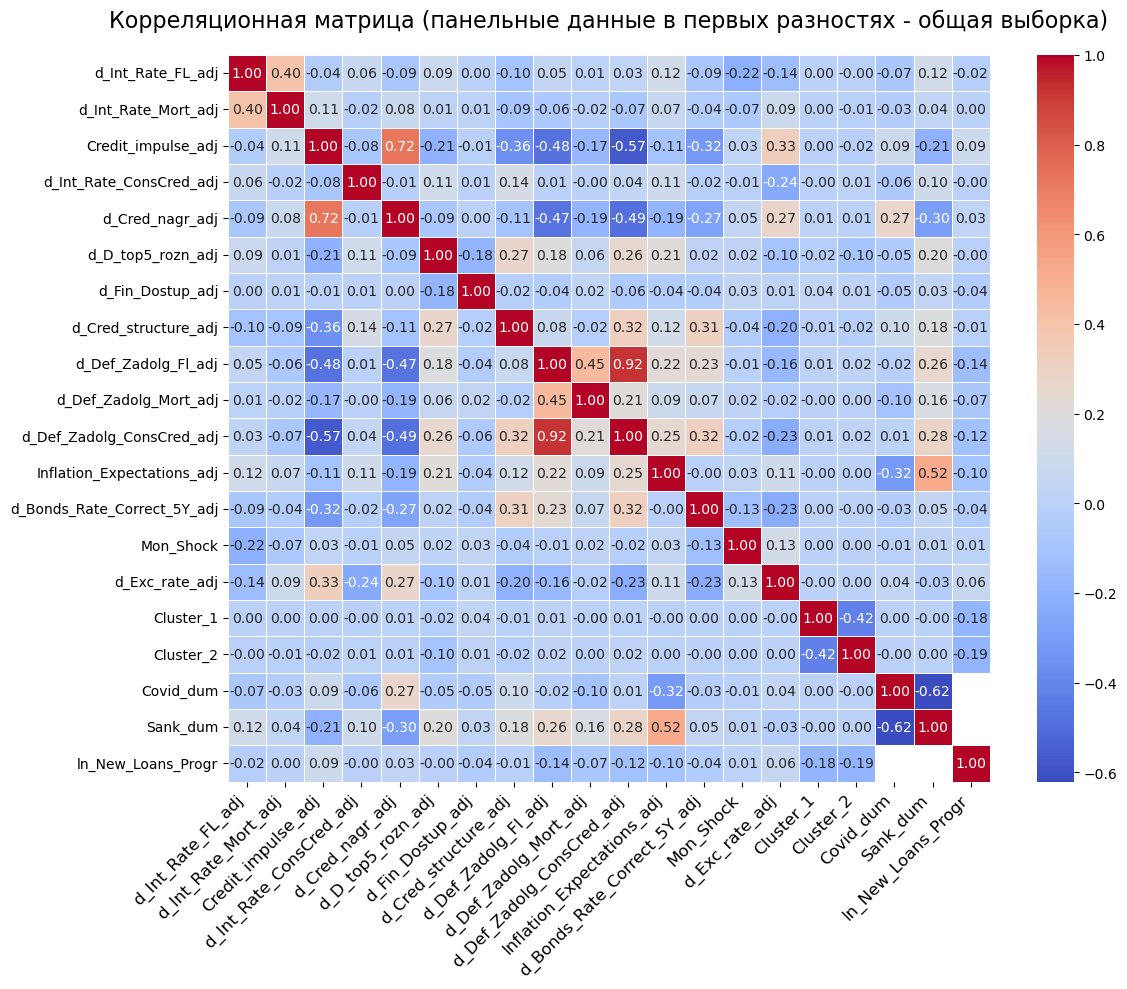

In [35]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - общая выборка)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [36]:
###############################
    #Добавление дополнительных переменных
###############################

# Кластеры * монетарный шок
df_exog['Mon_Shock_Cl1'] = df_exog['Mon_Shock'] * df_exog['Cluster_1']
df_exog['Mon_Shock_Cl2'] = df_exog['Mon_Shock'] * df_exog['Cluster_2']

# Кластеры * d_ln_ROISFIX
df_exog['d_ln_ROISFIX_Cl1'] = df_exog['d_ln_ROISFIX'] * df_exog['Cluster_1']
df_exog['d_ln_ROISFIX_Cl2'] = df_exog['d_ln_ROISFIX'] * df_exog['Cluster_2']

# Кластеры * d_ln_MIACR
df_exog['d_ln_MIACR_Cl1'] = df_exog['d_ln_MIACR'] * df_exog['Cluster_1']
df_exog['d_ln_MIACR_Cl2'] = df_exog['d_ln_MIACR'] * df_exog['Cluster_2']

# Covid * переменные интреса
df_exog['Mon_Shock_Covid']   = df_exog['Mon_Shock']   * df_exog['Covid_dum']
df_exog['d_ln_ROISFIX_Covid'] = df_exog['d_ln_ROISFIX'] * df_exog['Covid_dum']
df_exog['d_ln_MIACR_Covid']   = df_exog['d_ln_MIACR']   * df_exog['Covid_dum']

# Санкции * переменные интреса
df_exog['Mon_Shock_Sanctions']   = df_exog['Mon_Shock']   * df_exog['Sank_dum']
df_exog['d_ln_ROISFIX_Sanctions'] = df_exog['d_ln_ROISFIX'] * df_exog['Sank_dum']
df_exog['d_ln_MIACR_Sanctions']   = df_exog['d_ln_MIACR']   * df_exog['Sank_dum']


In [37]:
df_exog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6237 entries, 1 to 6317
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        6237 non-null   object        
 1   Date                          6237 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             6237 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        6237 non-null   float64       
 4   d_Int_Rate_Mort_adj           6237 non-null   float64       
 5   Credit_impulse_adj            6237 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      6237 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       6237 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  6237 non-null   float64       
 9   d_Cred_nagr_adj               6237 non-null   float64       
 10  d_D_top5_rozn_adj             6237 non-null   float64       
 11  d_Fin_Dostup_adj              6237 

In [38]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 1 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1")
print("="*60) 
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1
                   Variable      VIF
         Credit_impulse_adj 2.822971
            d_Cred_nagr_adj 2.598417
                   Sank_dum 2.366124
                  Covid_dum 1.959747
        d_Def_Zadolg_Fl_adj 1.577582
       d_Cred_structure_adj 1.573671
 Inflation_Expectations_adj 1.472016
d_Bonds_Rate_Correct_5Y_adj 1.282983
             d_Exc_rate_adj 1.220901
          d_D_top5_rozn_adj 1.220243
     d_Int_Rate_FL_lag1_adj 1.068773
           d_Fin_Dostup_adj 1.053484
                  Mon_Shock 1.033229


In [39]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 2 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2")
print("="*60) 
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2
                   Variable      VIF
         Credit_impulse_adj 2.866206
            d_Cred_nagr_adj 2.604520
                   Sank_dum 2.369310
                  Covid_dum 1.962585
        d_Def_Zadolg_Fl_adj 1.577708
       d_Cred_structure_adj 1.573869
 Inflation_Expectations_adj 1.551526
d_Bonds_Rate_Correct_5Y_adj 1.285820
             d_Exc_rate_adj 1.260157
          d_D_top5_rozn_adj 1.220674
            Mon_Shock_Covid 1.201127
                  Mon_Shock 1.107377
     d_Int_Rate_FL_lag1_adj 1.070154
           d_Fin_Dostup_adj 1.054125


In [40]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 3 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3")
print("="*60) 
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3
                   Variable      VIF
                  Mon_Shock 4.298887
              Mon_Shock_Cl1 3.948130
         Credit_impulse_adj 2.823497
            d_Cred_nagr_adj 2.599032
                   Sank_dum 2.366173
                  Covid_dum 1.959828
        d_Def_Zadolg_Fl_adj 1.577609
       d_Cred_structure_adj 1.573736
 Inflation_Expectations_adj 1.472024
              Mon_Shock_Cl2 1.316937
d_Bonds_Rate_Correct_5Y_adj 1.282986
             d_Exc_rate_adj 1.220931
          d_D_top5_rozn_adj 1.220299
     d_Int_Rate_FL_lag1_adj 1.069152
           d_Fin_Dostup_adj 1.053586


In [41]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 4 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 4")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 4
                    Variable      VIF
          Credit_impulse_adj 2.860079
             d_Cred_nagr_adj 2.585317
                    Sank_dum 2.339064
                   Covid_dum 1.968230
   d_Def_Zadolg_ConsCred_adj 1.832878
        d_Cred_structure_adj 1.488907
  Inflation_Expectations_adj 1.479724
 d_Bonds_Rate_Correct_5Y_adj 1.289324
              d_Exc_rate_adj 1.226491
           d_D_top5_rozn_adj 1.224783
            d_Fin_Dostup_adj 1.053724
d_Int_Rate_ConsCred_lag1_adj 1.047366
                   Mon_Shock 1.043466


In [42]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 5 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 5")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 5
                    Variable      VIF
          Credit_impulse_adj 2.905726
             d_Cred_nagr_adj 2.592414
                    Sank_dum 2.343178
                   Covid_dum 1.970301
   d_Def_Zadolg_ConsCred_adj 1.833090
  Inflation_Expectations_adj 1.557447
        d_Cred_structure_adj 1.488964
 d_Bonds_Rate_Correct_5Y_adj 1.292439
              d_Exc_rate_adj 1.265887
           d_D_top5_rozn_adj 1.225232
             Mon_Shock_Covid 1.201947
                   Mon_Shock 1.119818
            d_Fin_Dostup_adj 1.054391
d_Int_Rate_ConsCred_lag1_adj 1.049344


In [43]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 6 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 6")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 6
                    Variable      VIF
                   Mon_Shock 4.308461
               Mon_Shock_Cl1 3.948116
          Credit_impulse_adj 2.860685
             d_Cred_nagr_adj 2.585833
                    Sank_dum 2.339080
                   Covid_dum 1.968291
   d_Def_Zadolg_ConsCred_adj 1.832891
        d_Cred_structure_adj 1.488934
  Inflation_Expectations_adj 1.479726
               Mon_Shock_Cl2 1.316609
 d_Bonds_Rate_Correct_5Y_adj 1.289336
              d_Exc_rate_adj 1.226499
           d_D_top5_rozn_adj 1.224832
            d_Fin_Dostup_adj 1.053815
d_Int_Rate_ConsCred_lag1_adj 1.047564


In [44]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 7 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 7")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 7
                   Variable      VIF
         Credit_impulse_adj 2.704761
            d_Cred_nagr_adj 2.530139
                   Sank_dum 2.252205
                  Covid_dum 1.829370
       d_Cred_structure_adj 1.507736
 Inflation_Expectations_adj 1.463011
d_Bonds_Rate_Correct_5Y_adj 1.262072
          d_D_top5_rozn_adj 1.212519
             d_Exc_rate_adj 1.206475
      d_Def_Zadolg_Mort_adj 1.065957
           d_Fin_Dostup_adj 1.053018
   d_Int_Rate_Mort_lag1_adj 1.039261
                  Mon_Shock 1.033491


In [45]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 8 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 8")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 8
                   Variable      VIF
         Credit_impulse_adj 2.750748
            d_Cred_nagr_adj 2.537314
                   Sank_dum 2.256711
                  Covid_dum 1.831492
 Inflation_Expectations_adj 1.543417
       d_Cred_structure_adj 1.507746
d_Bonds_Rate_Correct_5Y_adj 1.265280
             d_Exc_rate_adj 1.244439
          d_D_top5_rozn_adj 1.213041
            Mon_Shock_Covid 1.201999
                  Mon_Shock 1.108115
      d_Def_Zadolg_Mort_adj 1.066156
           d_Fin_Dostup_adj 1.053600
   d_Int_Rate_Mort_lag1_adj 1.041189


In [46]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 9 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 9")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 9
                   Variable      VIF
                  Mon_Shock 4.298765
              Mon_Shock_Cl1 3.948094
         Credit_impulse_adj 2.705356
            d_Cred_nagr_adj 2.530653
                   Sank_dum 2.252217
                  Covid_dum 1.829414
       d_Cred_structure_adj 1.507756
 Inflation_Expectations_adj 1.463020
              Mon_Shock_Cl2 1.316795
d_Bonds_Rate_Correct_5Y_adj 1.262074
          d_D_top5_rozn_adj 1.212579
             d_Exc_rate_adj 1.206487
      d_Def_Zadolg_Mort_adj 1.065998
           d_Fin_Dostup_adj 1.053113
   d_Int_Rate_Mort_lag1_adj 1.039522


In [47]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 10 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr'

]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10
                   Variable      VIF
         Credit_impulse_adj 2.501167
       d_Cred_structure_adj 2.281980
 Inflation_Expectations_adj 2.257636
d_Bonds_Rate_Correct_5Y_adj 2.137279
             d_Exc_rate_adj 1.840026
            d_Cred_nagr_adj 1.585013
          d_D_top5_rozn_adj 1.434625
      d_Def_Zadolg_Mort_adj 1.216730
           d_Fin_Dostup_adj 1.110832
                  Mon_Shock 1.103173
   d_Int_Rate_Mort_lag1_adj 1.055214
         ln_New_Loans_Progr 1.025996


In [48]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 11 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10
                   Variable      VIF
                  Mon_Shock 4.270127
              Mon_Shock_Cl1 3.881609
         Credit_impulse_adj 2.506092
       d_Cred_structure_adj 2.288292
 Inflation_Expectations_adj 2.258319
d_Bonds_Rate_Correct_5Y_adj 2.137955
             d_Exc_rate_adj 1.840091
            d_Cred_nagr_adj 1.585320
          d_D_top5_rozn_adj 1.437747
              Mon_Shock_Cl2 1.328747
      d_Def_Zadolg_Mort_adj 1.217639
           d_Fin_Dostup_adj 1.126515
   d_Int_Rate_Mort_lag1_adj 1.055681
         ln_New_Loans_Progr 1.031447


In [49]:
###############################
    #Тест на стационарность I(1) рядов для 1-го кластера
###############################

custom_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj'
]
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ")
print("="*70)
# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ
Тестирование 17 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_FL_adj
  2. d_Int_Rate_FL_lag1_adj
  3. d_Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. d_Int_Rate_Mort_lag1_adj
  6. d_Int_Rate_ConsCred_adj
  7. d_Int_Rate_ConsCred_lag1_adj
  8. d_Cred_nagr_adj
  9. d_D_top5_rozn_adj
  10. d_Fin_Dostup_adj
  11. d_Cred_structure_adj
  12. d_Def_Zadolg_Fl_adj
  13. d_Def_Zadolg_Mort_adj
  14. d_Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. d_Bonds_Rate_Correct_5Y_adj
  17. d_Exc_rate_adj



РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                  Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           d_Int_Rate_FL_adj    0.035774         0.483   1.266282 2.054123e-01 -7.379504  -7.984880        91.358025   -9.035959     -8.863650          100.000000                True             False             True                True                  True
      d_Int_Rate_FL_lag1_adj    0.035330         0.480   0.840280 4.007511e-01 -7.222511  -7.825490        91.358025   -8.914331     -8.615306          100.000000                True             False             True                True                  True
         d_Int_Rate_Mort_adj    0.045198         0.484  -6.839545 7.944534e-12 -8.311619  -8.993843        97.530864  -10.968763    -10.952126          100.000000                True

In [50]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 1")
print("="*70)

df_exog_clus_one = df_exog[df_exog['Cluster_1'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_one, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 1
Тестирование 17 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_FL_adj
  2. d_Int_Rate_FL_lag1_adj
  3. d_Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. d_Int_Rate_Mort_lag1_adj
  6. d_Int_Rate_ConsCred_adj
  7. d_Int_Rate_ConsCred_lag1_adj
  8. d_Cred_nagr_adj
  9. d_D_top5_rozn_adj
  10. d_Fin_Dostup_adj
  11. d_Cred_structure_adj
  12. d_Def_Zadolg_Fl_adj
  13. d_Def_Zadolg_Mort_adj
  14. d_Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. d_Bonds_Rate_Correct_5Y_adj
  17. d_Exc_rate_adj

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                  Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           d_Int_Rate_FL_adj    0.034816         0.487   0.614151 5.391157e-01 -7.716172  -8.220459      

In [51]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 2")
print("="*70)

df_exog_clus_two = df_exog[df_exog['Cluster_2'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_two, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 2
Тестирование 17 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_FL_adj
  2. d_Int_Rate_FL_lag1_adj
  3. d_Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. d_Int_Rate_Mort_lag1_adj
  6. d_Int_Rate_ConsCred_adj
  7. d_Int_Rate_ConsCred_lag1_adj
  8. d_Cred_nagr_adj
  9. d_D_top5_rozn_adj
  10. d_Fin_Dostup_adj
  11. d_Cred_structure_adj
  12. d_Def_Zadolg_Fl_adj
  13. d_Def_Zadolg_Mort_adj
  14. d_Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. d_Bonds_Rate_Correct_5Y_adj
  17. d_Exc_rate_adj

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                  Переменная  Hadri_Stat  Hadri_PValue  LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           d_Int_Rate_FL_adj    0.042398         0.510 -0.014732 9.882462e-01 -6.292897  -6.584261        

In [52]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 3")
print("="*70)

df_exog_clus_three = df_exog[(df_exog['Cluster_1'] == 0) & (df_exog['Cluster_2'] == 0)].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_three, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 3
Тестирование 17 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_FL_adj
  2. d_Int_Rate_FL_lag1_adj
  3. d_Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. d_Int_Rate_Mort_lag1_adj
  6. d_Int_Rate_ConsCred_adj
  7. d_Int_Rate_ConsCred_lag1_adj
  8. d_Cred_nagr_adj
  9. d_D_top5_rozn_adj
  10. d_Fin_Dostup_adj
  11. d_Cred_structure_adj
  12. d_Def_Zadolg_Fl_adj
  13. d_Def_Zadolg_Mort_adj
  14. d_Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. d_Bonds_Rate_Correct_5Y_adj
  17. d_Exc_rate_adj

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                  Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           d_Int_Rate_FL_adj    0.036504         0.523   0.194522 8.457673e-01 -6.730360  -7.847715      

In [53]:
df_exog_clus_one.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4312 entries, 1 to 6317
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        4312 non-null   object        
 1   Date                          4312 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             4312 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        4312 non-null   float64       
 4   d_Int_Rate_Mort_adj           4312 non-null   float64       
 5   Credit_impulse_adj            4312 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      4312 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       4312 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  4312 non-null   float64       
 9   d_Cred_nagr_adj               4312 non-null   float64       
 10  d_D_top5_rozn_adj             4312 non-null   float64       
 11  d_Fin_Dostup_adj              4312 

In [54]:
df_exog_clus_two.info()

<class 'pandas.core.frame.DataFrame'>
Index: 462 entries, 79 to 6083
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        462 non-null    object        
 1   Date                          462 non-null    datetime64[ns]
 2   d_Int_Rate_FL_adj             462 non-null    float64       
 3   d_Int_Rate_FL_lag1_adj        462 non-null    float64       
 4   d_Int_Rate_Mort_adj           462 non-null    float64       
 5   Credit_impulse_adj            462 non-null    float64       
 6   d_Int_Rate_Mort_lag1_adj      462 non-null    float64       
 7   d_Int_Rate_ConsCred_adj       462 non-null    float64       
 8   d_Int_Rate_ConsCred_lag1_adj  462 non-null    float64       
 9   d_Cred_nagr_adj               462 non-null    float64       
 10  d_D_top5_rozn_adj             462 non-null    float64       
 11  d_Fin_Dostup_adj              462 n

In [55]:
df_exog_clus_three.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 313 to 6239
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        1463 non-null   object        
 1   Date                          1463 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             1463 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        1463 non-null   float64       
 4   d_Int_Rate_Mort_adj           1463 non-null   float64       
 5   Credit_impulse_adj            1463 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      1463 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       1463 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  1463 non-null   float64       
 9   d_Cred_nagr_adj               1463 non-null   float64       
 10  d_D_top5_rozn_adj             1463 non-null   float64       
 11  d_Fin_Dostup_adj              146

In [56]:
class ModelResultsAggregator:
    '''
    Агрегирует результаты панельных регрессий (POOL, FE, RE)
    из разных спецификаций и подвыборок в единую таблицу.
    '''

    def __init__(self):
        self.results_storage = []
        self.dependent_vars = []
        self.subsamples = []

    def add_model_results(self,
                          model_results,
                          dependent_variable: str,
                          subsample_name: str,
                          model_type: str,
                          specification_name: str,
                          se_type: str | None = None):
        """
        Добавляет результаты одной модели в хранилище.

        specification_name — уникальное имя столбца
        (например 'Модель_1', 'Модель_2', ...).
        se_type — строка с типом стандартных ошибок
        (например 'robust', 'clustered (region)'...)
        """
        coefficients = model_results.params
        pvalues = model_results.pvalues

        # R^2
        try:
            r_squared = model_results.rsquared
        except Exception:
            r_squared = None

        # N
        try:
            nobs = int(model_results.nobs)
        except Exception:
            nobs = None

        # если тип SE не передан, попытаемся вытащить из атрибута модели (если есть)
        if se_type is None:
            se_type = getattr(model_results, 'cov_type', None)

        for var_name in coefficients.index:
            coef = coefficients[var_name]
            pval = pvalues[var_name]
            stars = self._get_significance_stars(pval)

            self.results_storage.append({
                'dependent_var': dependent_variable,
                'subsample': subsample_name,
                'model_type': model_type,
                'specification': specification_name,
                'variable': var_name,
                'coefficient': coef,
                'pvalue': pval,
                'stars': stars,
                'r_squared': r_squared,
                'nobs': nobs,
                'se_type': se_type
            })

        if dependent_variable not in self.dependent_vars:
            self.dependent_vars.append(dependent_variable)
        if subsample_name not in self.subsamples:
            self.subsamples.append(subsample_name)

    def _get_significance_stars(self, pvalue):
        if pd.isna(pvalue):
            return ''
        if pvalue < 0.01:
            return '***'
        elif pvalue < 0.05:
            return '**'
        elif pvalue < 0.10:
            return '*'
        else:
            return ''

    def build_table(self,
                    dependent_var_filter: str = None,
                    specification_filter: list | None = None,
                    include_pvalues: bool = True,
                    decimals: int = 3) -> pd.DataFrame:
        """
        Итоговая таблица:
        1-я строка: 'Зависимая переменная'
        2-я–...: коэффициенты и p-value по регрессорам
        строка под R^2: 'Тип стандартных ошибок'
        следующая строка: 'n-obs'
        предпоследняя строка: 'Метод оценки' (POOL/FE/RE)
        последняя строка: 'Выборка'.
        """
        df = pd.DataFrame(self.results_storage)

        # фильтры
        if dependent_var_filter:
            df = df[df['dependent_var'] == dependent_var_filter]
        if specification_filter is not None:
            df = df[df['specification'].isin(specification_filter)]

        # порядок столбцов по спецификациям
        col_order = list(dict.fromkeys(df['specification']))

        # тело таблицы
        body_dict = {}
        for spec in col_order:
            subset = df[df['specification'] == spec]
            col_data = {}
            for _, row in subset.iterrows():
                var = row['variable']
                coef = row['coefficient']
                stars = row['stars']
                pval = row['pvalue']

                if include_pvalues and pd.notna(pval):
                    cell = f"{coef:.{decimals}f}{stars} ({pval:.{decimals}f})"
                else:
                    cell = f"{coef:.{decimals}f}{stars}"

                col_data[var] = cell
            body_dict[spec] = col_data

        body_df = pd.DataFrame(body_dict).reindex(columns=col_order).fillna('')

        # Зависимая переменная (верхняя строка)
        dep_names = (df.groupby('specification')['dependent_var']
                       .first()
                       .reindex(col_order))
        dep_row = pd.DataFrame([dep_names], index=['Зависимая переменная'])

        # R^2
        r2_vals = (df.groupby('specification')['r_squared']
                     .max()
                     .round(decimals)
                     .reindex(col_order))
        r2_row = pd.DataFrame([r2_vals], index=['R^2'])

        # Тип стандартных ошибок (под R^2)
        se_vals = (df.groupby('specification')['se_type']
                     .first()
                     .reindex(col_order))
        se_row = pd.DataFrame([se_vals], index=['Тип стандартных ошибок'])

        # n-obs (число наблюдений)
        nobs_vals = (df.groupby('specification')['nobs']
                       .max()
                       .reindex(col_order))
        nobs_row = pd.DataFrame([nobs_vals], index=['n-obs'])

        # Метод оценки (предпоследняя строка)
        model_names = (df.groupby('specification')['model_type']
                         .first()
                         .reindex(col_order))
        model_row = pd.DataFrame([model_names], index=['Метод оценки'])

        # Выборка (последняя строка)
        subsample_vals = (df.groupby('specification')['subsample']
                            .first()
                            .reindex(col_order))
        subsample_row = pd.DataFrame([subsample_vals], index=['Выборка'])

        # Итог: Зависимая переменная -> тело -> R^2 -> Тип SE -> n-obs -> Метод -> Выборка
        output_df = pd.concat(
            [dep_row, body_df, r2_row, se_row, nobs_row, model_row, subsample_row],
            axis=0
        )
        return output_df

    def build_summary_table(self,
                            dependent_var_filter: str = None,
                            decimals: int = 3) -> pd.DataFrame:
        """
        Сводная таблица по спецификациям (как дополнение к основной).
        Внизу остаётся строка с N (как раньше).
        """
        df = pd.DataFrame(self.results_storage)

        if dependent_var_filter:
            df = df[df['dependent_var'] == dependent_var_filter]

        df['col_name'] = df['specification']

        df['formatted_coef'] = (df['coefficient'].round(decimals).astype(str) +
                                df['stars'])
        df['formatted_pval'] = '(' + df['pvalue'].round(decimals).astype(str) + ')'

        result = df.groupby(['variable', 'col_name']).apply(
            lambda x: ' '.join([x.iloc[0]['formatted_coef'],
                                x.iloc[0]['formatted_pval']])
        ).unstack(fill_value='')

        # строка с N внизу (можно оставить как N, чтобы не ломать старый код)
        nobs_table = (df.groupby('col_name')['nobs']
                        .max()
                        .rename('N')
                        .to_frame()
                        .T)
        nobs_table = nobs_table.astype('Int64').astype(str)

        result = pd.concat([result, nobs_table])
        return result


In [57]:
###############################
# Построение линейных моделей на панельных данных - общая выборка
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_FL_adj

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.1240
Estimator:                  PooledOLS   R-squared (Between):              0.7560
No. Observations:                6237   R-squared (Within):               0.1197
Date:                 Вт, дек 30 2025   R-squared (Overall):              0.1240
Time:                        15:04:02   Log-likelihood                   -8689.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      73.437
Entities:                          81   P-value                           0.0000
Avg Obs:                       77.000   Distribution:                 F(12,6225)
Min Obs:                       77.000                                       

In [58]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
from scipy.stats import f

print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -356.9367
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 3147.5448
p-значение: 0.000000
N (регионов): 81, T (периодов): 77

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -20.8595
p-значение: 1.000000
df: (80, 6144)

Вывод: p >= 0.05 - Pooled адекватна


In [59]:
# Добавляем результаты в сводную таблицу
aggregator_Int_FL = ModelResultsAggregator()

aggregator_Int_FL.add_model_results(
    re_res,
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_1',
    se_type = 'Clustered'
)


In [60]:
###############################
# Построение линейных моделей на панельных данных - общая выборка
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_FL_adj

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.1255
Estimator:                  PooledOLS   R-squared (Between):              0.7579
No. Observations:                6237   R-squared (Within):               0.1211
Date:                 Вт, дек 30 2025   R-squared (Overall):              0.1255
Time:                        15:04:02   Log-likelihood                   -8684.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      68.683
Entities:                          81   P-value                           0.0000
Avg Obs:                       77.000   Distribution:                 F(13,6224)
Min Obs:                       77.000                                       

In [61]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
from scipy.stats import f

print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -412.5781
p-значение: 1.000000
df: 13

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 3147.6176
p-значение: 0.000000
N (регионов): 81, T (периодов): 77

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -24.8369
p-значение: 1.000000
df: (80, 6143)

Вывод: p >= 0.05 - Pooled адекватна


In [62]:
# Добавляем результаты в сводную таблицу

aggregator_Int_FL.add_model_results(
    re_res,
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_2',
    se_type = 'Clustered'
)


In [63]:
###############################
# Построение линейных моделей на панельных данных - общая выборка
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_FL_adj

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.1245
Estimator:                  PooledOLS   R-squared (Between):              0.7560
No. Observations:                6237   R-squared (Within):               0.1202
Date:                 Вт, дек 30 2025   R-squared (Overall):              0.1245
Time:                        15:04:03   Log-likelihood                   -8687.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      63.208
Entities:                          81   P-value                           0.0000
Avg Obs:                       77.000   Distribution:                 F(14,6223)
Min Obs:                       77.000                                       

In [64]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
from scipy.stats import f

print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -381.9011
p-значение: 1.000000
df: 14

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 3147.5381
p-значение: 0.000000
N (регионов): 81, T (периодов): 77

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -20.8527
p-значение: 1.000000
df: (80, 6142)

Вывод: p >= 0.05 - Pooled адекватна


In [65]:
# Добавляем результаты в сводную таблицу
aggregator_Int_FL.add_model_results(
    re_res,
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_3',
    se_type = 'Clustered'
)

In [66]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_ConsCred_adj

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.2563
Estimator:                       PooledOLS   R-squared (Between):              0.8327
No. Observations:                     6237   R-squared (Within):               0.2512
Date:                      Вт, дек 30 2025   R-squared (Overall):              0.2563
Time:                             15:04:03   Log-likelihood                -1.211e+04
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      164.96
Entities:                               81   P-value                           0.0000
Avg Obs:                            77.000   Distribution:                 F(13,6224)
Min Obs:            

In [67]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -482.0450
p-значение: 1.000000
df: 13

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 3147.1655
p-значение: 0.000000
N (регионов): 81, T (периодов): 77

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -34.8411
p-значение: 1.000000
df: (80, 6143)

Вывод: p >= 0.05 - Pooled адекватна


In [68]:
# Добавляем результаты в сводную таблицу
aggregator_Int_ConsCred = ModelResultsAggregator()

aggregator_Int_ConsCred.add_model_results(
    fe_res,
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_4',
    se_type = 'Clustered'
)

In [69]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_ConsCred_adj

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.2592
Estimator:                       PooledOLS   R-squared (Between):              0.8230
No. Observations:                     6237   R-squared (Within):               0.2543
Date:                      Вт, дек 30 2025   R-squared (Overall):              0.2592
Time:                             15:04:04   Log-likelihood                 -1.21e+04
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      155.56
Entities:                               81   P-value                           0.0000
Avg Obs:                            77.000   Distribution:                 F(14,6223)
Min Obs:            

In [70]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -489.3293
p-значение: 1.000000
df: 14

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 3146.4000
p-значение: 0.000000
N (регионов): 81, T (периодов): 77

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -40.7136
p-значение: 1.000000
df: (80, 6142)

Вывод: p >= 0.05 - Pooled адекватна


In [71]:
# Добавляем результаты в сводную таблицу
aggregator_Int_ConsCred.add_model_results(
    fe_res,
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_5',
    se_type = 'Clustered'
)

In [72]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_ConsCred_adj

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.2563
Estimator:                       PooledOLS   R-squared (Between):              0.8327
No. Observations:                     6237   R-squared (Within):               0.2512
Date:                      Вт, дек 30 2025   R-squared (Overall):              0.2563
Time:                             15:04:05   Log-likelihood                -1.211e+04
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      142.93
Entities:                               81   P-value                           0.0000
Avg Obs:                            77.000   Distribution:                 F(15,6222)
Min Obs:            

In [73]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -529.1838
p-значение: 1.000000
df: 15

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 3147.1671
p-значение: 0.000000
N (регионов): 81, T (периодов): 77

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -34.8286
p-значение: 1.000000
df: (80, 6141)

Вывод: p >= 0.05 - Pooled адекватна


In [74]:
# Добавляем результаты в сводную таблицу
aggregator_Int_ConsCred.add_model_results(
    fe_res,
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_6',
    se_type = 'Clustered'
)

In [75]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.0994
Estimator:                   PooledOLS   R-squared (Between):              0.5823
No. Observations:                 6237   R-squared (Within):               0.0977
Date:                  Вт, дек 30 2025   R-squared (Overall):              0.0994
Time:                         15:04:05   Log-likelihood                   -5691.6
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      52.862
Entities:                           81   P-value                           0.0000
Avg Obs:                        77.000   Distribution:                 F(13,6224)
Min Obs:                        77.000                          

In [76]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 111.7728
p-значение: 0.000000
df: 13

Вывод: p < 0.05 - Используйте FIXED EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 3149.3575
p-значение: 0.000000
N (регионов): 81, T (периодов): 77

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -22.9721
p-значение: 1.000000
df: (80, 6143)

Вывод: p >= 0.05 - Pooled адекватна


In [77]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort = ModelResultsAggregator()

aggregator_Int_Mort.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_7',
    se_type = 'Clustered'
)

In [78]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1003
Estimator:                   PooledOLS   R-squared (Between):              0.5870
No. Observations:                 6237   R-squared (Within):               0.0986
Date:                  Вт, дек 30 2025   R-squared (Overall):              0.1003
Time:                         15:04:06   Log-likelihood                   -5688.8
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      49.534
Entities:                           81   P-value                           0.0000
Avg Obs:                        77.000   Distribution:                 F(14,6223)
Min Obs:                        77.000                          

In [79]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 831.9043
p-значение: 0.000000
df: 14

Вывод: p < 0.05 - Используйте FIXED EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 3149.4635
p-значение: 0.000000
N (регионов): 81, T (периодов): 77

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -22.1881
p-значение: 1.000000
df: (80, 6142)

Вывод: p >= 0.05 - Pooled адекватна


In [80]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_8',
    se_type = 'Clustered'
)

In [81]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.0998
Estimator:                   PooledOLS   R-squared (Between):              0.5829
No. Observations:                 6237   R-squared (Within):               0.0981
Date:                  Вт, дек 30 2025   R-squared (Overall):              0.0998
Time:                         15:04:07   Log-likelihood                   -5690.5
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      45.970
Entities:                           81   P-value                           0.0000
Avg Obs:                        77.000   Distribution:                 F(15,6222)
Min Obs:                        77.000                          

In [82]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -373.1547
p-значение: 1.000000
df: 15

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 3149.3688
p-значение: 0.000000
N (регионов): 81, T (периодов): 77

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -22.9557
p-значение: 1.000000
df: (80, 6141)

Вывод: p >= 0.05 - Pooled адекватна


In [83]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_9',
    se_type = 'Clustered'
)

In [84]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.2733
Estimator:                   PooledOLS   R-squared (Between):             -0.8324
No. Observations:                 1539   R-squared (Within):               0.2761
Date:                  Вт, дек 30 2025   R-squared (Overall):              0.2733
Time:                         15:04:08   Log-likelihood                   -1919.7
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      47.846
Entities:                           81   P-value                           0.0000
Avg Obs:                        19.000   Distribution:                 F(12,1527)
Min Obs:                        19.000                          

In [85]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 30.8441
p-значение: 0.002081
df: 12

Вывод: p < 0.05 - Используйте FIXED EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 801.5955
p-значение: 0.000000
N (регионов): 81, T (периодов): 19

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -5.0091
p-значение: 1.000000
df: (80, 1446)

Вывод: p >= 0.05 - Pooled адекватна


In [86]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_10',
    se_type = 'Clustered'
)

In [87]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.2735
Estimator:                   PooledOLS   R-squared (Between):             -0.8711
No. Observations:                 1539   R-squared (Within):               0.2765
Date:                  Вт, дек 30 2025   R-squared (Overall):              0.2735
Time:                         15:04:08   Log-likelihood                   -1919.5
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      41.008
Entities:                           81   P-value                           0.0000
Avg Obs:                        19.000   Distribution:                 F(14,1525)
Min Obs:                        19.000                          

In [88]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 3.9289
p-значение: 0.995879
df: 14

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 801.3674
p-значение: 0.000000
N (регионов): 81, T (периодов): 19

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -5.1198
p-значение: 1.000000
df: (80, 1444)

Вывод: p >= 0.05 - Pooled адекватна


In [89]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_11',
    se_type = 'Clustered'
)

In [90]:
full_table_Int_FL = aggregator_Int_FL.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table_Int_FL)

                                       Модель_1            Модель_2  \
Зависимая переменная          d_Int_Rate_FL_adj   d_Int_Rate_FL_adj   
d_Int_Rate_FL_lag1_adj        -0.123*** (0.000)   -0.123*** (0.000)   
d_Cred_nagr_adj               -6.865*** (0.006)   -6.696*** (0.008)   
d_D_top5_rozn_adj             36.783*** (0.000)   36.926*** (0.000)   
d_Fin_Dostup_adj                  0.076 (0.289)       0.079 (0.272)   
Credit_impulse_adj              -0.007* (0.058)      -0.006 (0.121)   
d_Cred_structure_adj         -54.927*** (0.000)  -54.499*** (0.000)   
d_Def_Zadolg_Fl_adj              -0.249 (0.112)      -0.231 (0.140)   
Mon_Shock                     -0.169*** (0.000)   -0.177*** (0.000)   
d_Bonds_Rate_Correct_5Y_adj   -0.544*** (0.000)   -0.552*** (0.000)   
Inflation_Expectations_adj    -0.004*** (0.002)   -0.003*** (0.005)   
Covid_dum                      0.068*** (0.001)    0.065*** (0.001)   
Sank_dum                       0.286*** (0.000)    0.283*** (0.000)   
Mon_Sh

In [91]:
# ###############################
# # Построение линейных моделей на панельных данных (КАК В ИССЛЕДОВАНИИ СКУРАТОВА & ЗВЕРЕВА)
# # (Int_Rate_ConsCred зависимая переменная)
# # Модель в первой разности - первый лаг ДКП
# ###############################

# exog_vars_initial = [
#     'd_Mon_Shock',         # Монетарный индикатор
#     'D_top5_rozn',         # Особенности банковского сектора (пока только топ-5)
#     'd_Ex_Rate',
#     'Bonds_Rate_Correct_5Y',
# ]

# dependent_var = 'd_Int_Rate_ConsCred'

# y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
#     df_reg, df_reg, dependent_var, exog_vars_initial, cov_type='clustered', cluster_entity=True, df_name='df_reg'
# )

# # Сохраняем результаты модели для экспорта
# pooled_res_1 = pooled_res if pooled_success else None
# fe_res_1 = fe_res if fe_success else None
# re_res_1 = re_res if re_success else None

In [92]:
# run_panel_model_diagnostics(
#     y, X, pooled_res, fe_res, re_res,
#     pooled_success, fe_success, re_success
# )


In [93]:
# # ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====

# run_spec_tests(
#     y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
# )


In [94]:
full_table_Int_ConsCred = aggregator_Int_ConsCred.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table_Int_ConsCred)

                                             Модель_4  \
Зависимая переменная          d_Int_Rate_ConsCred_adj   
d_Int_Rate_ConsCred_lag1_adj        -0.408*** (0.000)   
d_Cred_nagr_adj                        16.944 (0.110)   
d_D_top5_rozn_adj                   30.870*** (0.000)   
d_Fin_Dostup_adj                     0.147*** (0.005)   
Credit_impulse_adj                    -0.022* (0.057)   
d_Cred_structure_adj                64.681*** (0.000)   
d_Def_Zadolg_ConsCred_adj           -0.731*** (0.000)   
Mon_Shock                           -0.049*** (0.000)   
d_Bonds_Rate_Correct_5Y_adj         -1.097*** (0.000)   
d_Exc_rate_adj                      -0.124*** (0.000)   
Inflation_Expectations_adj           0.148*** (0.000)   
Covid_dum                           -0.182*** (0.001)   
Sank_dum                             0.180*** (0.000)   
Mon_Shock_Covid                                         
Mon_Shock_Cl1                                           
Mon_Shock_Cl2                  

In [95]:
full_table_Int_Mort = aggregator_Int_Mort.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table_Int_Mort)

                                        Модель_7             Модель_8  \
Зависимая переменная         d_Int_Rate_Mort_adj  d_Int_Rate_Mort_adj   
d_Int_Rate_Mort_lag1_adj       -0.263*** (0.000)    -0.263*** (0.000)   
d_Cred_nagr_adj                  2.865** (0.021)      2.775** (0.024)   
d_D_top5_rozn_adj                 8.460* (0.080)       8.422* (0.081)   
d_Fin_Dostup_adj                   0.037 (0.306)        0.036 (0.322)   
Credit_impulse_adj              0.007*** (0.005)      0.006** (0.013)   
d_Cred_structure_adj          -13.658*** (0.000)   -13.756*** (0.000)   
d_Def_Zadolg_Mort_adj             -0.186 (0.203)       -0.193 (0.193)   
Mon_Shock                      -0.038*** (0.000)    -0.035*** (0.000)   
d_Bonds_Rate_Correct_5Y_adj       -0.048 (0.247)       -0.043 (0.300)   
d_Exc_rate_adj                  0.008*** (0.000)     0.009*** (0.000)   
Inflation_Expectations_adj     -0.005*** (0.000)    -0.005*** (0.000)   
Covid_dum                      -0.049*** (0.001)   

In [96]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1
###############################
descriptive_df = df_exog_clus_one[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Covid_dum',
    'Sank_dum'
]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])

KeyError: ('d_Int_Rate_FL_adj', 'd_Int_Rate_Mort_adj', 'Credit_impulse_adj', 'd_Int_Rate_ConsCred_adj', 'd_Cred_nagr_adj', 'd_D_top5_rozn_adj', 'd_Fin_Dostup_adj', 'd_Cred_structure_adj', 'd_Def_Zadolg_Fl_adj', 'd_Def_Zadolg_Mort_adj', 'd_Def_Zadolg_ConsCred_adj', 'd_ln_New_Loans_Fl_adj', 'd_ln_New_Loans_Mort_adj', 'd_ln_New_Loans_ConsCred_adj', 'Inflation_Expectations_adj', 'd_Bonds_Rate_Correct_5Y_adj', 'Mon_Shock', 'd_Exc_rate_adj', 'Covid_dum', 'Sank_dum')

In [ ]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - кластер 1)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [ ]:
###############################
# Построение линейных моделей на панельных данных - кластер 1
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_4'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 1)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_1',
    model_type='FE',
    specification_name='Модель_5'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 1)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_6'
)

In [ ]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2
###############################
descriptive_df = df_exog_clus_two[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])

In [ ]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - кластер 2)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [ ]:
###############################
# Построение линейных моделей на панельных данных - кластер 2
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_7'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 2)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_8'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 2)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_9'
)

In [ ]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 3
###############################
descriptive_df = df_exog_clus_three[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])

In [ ]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 3
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - кластер 3)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [ ]:
###############################
# Построение линейных моделей на панельных данных - кластер 3
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                               
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_10'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 3)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                             
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_11'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 3)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_12'
)

In [ ]:
full_table = aggregator.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table)

In [ ]:
#full_table.to_excel('results_panel.xlsx')

In [ ]:
###########################################
 #ПОСТРОЕНИЕ МОДЕЛЕЙ С ROISFIX
###########################################
df_exog = pd.read_excel('exog.xlsx')

In [ ]:
# df_roisfix.head()

In [ ]:
df_exog.head()

In [ ]:
df_exog = df_exog.merge(
    df_roisfix,
    on='Date',         
    how='left'         
)


In [ ]:
df_exog.info()

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 1 спецификация (ROISFIX)
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                   
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1 (ROISFIX)")
print("="*60) 
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 2 спецификация (ROISFIX)
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                   
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2 (ROISFIX)")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 3 спецификация (ROISFIX)
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                     
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3 (ROISFIX)")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)
###############################
descriptive_df = df_exog[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_ln_ROISFIX',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])

In [ ]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - общая выборка (ROISFIX))",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [ ]:
###############################
# Построение линейных моделей на панельных данных - общая выборка ROISFIX
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА ROISFIX)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
from scipy.stats import f

print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix = ModelResultsAggregator()

aggregator_roisfix.add_model_results(
    re_res,
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_13'
)


In [ ]:
###############################
# Построение линейных моделей на панельных данных (общая выборка) ROISFIX
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА ROISFIX)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
from scipy.stats import f

print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res,
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_14'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (общая выборка) ROISFIX
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_15'
)

In [ ]:
df_exog_clus_one = df_exog[df_exog['Cluster_1'] == 1].copy()

In [ ]:
df_exog_clus_two = df_exog[df_exog['Cluster_2'] == 1].copy()

In [ ]:
df_exog_clus_three = df_exog[(df_exog['Cluster_1'] == 0) & (df_exog['Cluster_2'] == 0)].copy()

In [ ]:
###############################
# Построение линейных моделей на панельных данных - кластер 1 ROISFIX
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_16'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 1 ROISFIX)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_17'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 1 ROISFIX)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_18'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных - кластер 2 ROISFIX
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_19'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 2 ROISFIX)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_20'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 2 ROISFIX)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_21'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных - кластер 3 ROISFIX
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                               
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_22'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 3 ROISFIX)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                             
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_23'
)

In [ ]:
###############################
# Построение линейных моделей на панельных данных (кластер 3 ROISFIX)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

In [ ]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

In [ ]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_24'
)

In [ ]:
full_table = aggregator_roisfix.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table)

In [ ]:
full_table_Int_FL.to_excel('results_panel_Int_FL.xlsx')
full_table_Int_ConsCred.to_excel('results_panel_Int_ConsCred.xlsx')
full_table_Int_Mort.to_excel('results_panel_Int_Mort.xlsx')

In [ ]:
'''df_clean.head()

###############################
# Построение PVAR S-GMM моделей
###############################
from pydynpd import regression

# Подготовка данных
df_for_gmm = df_clean.reset_index()
df_for_gmm = df_for_gmm.sort_values(['Region', 'Date'])

# System GMM 

# Используем спецификацию, которая работала ранее
command_str_system = (
    'd_Int_Rate_FL_adj L1.d_Int_Rate_FL_adj '
    'd_Cred_nagr_adj d_D_top5_rozn_adj '
    'Mon_Shock d_Bonds_Rate_Correct_5Y_adj d_Exc_rate_adj | '
    'gmm(d_Int_Rate_FL_adj, 2:4) '
    'iv(d_Cred_nagr_adj d_D_top5_rozn_adj Mon_Shock d_Bonds_Rate_Correct_5Y_adj d_Exc_rate_adj) | '
    'collapse'
)

mydpd_system = regression.abond(command_str_system, df_for_gmm, ['Region', 'Date'])'''
